# Imagen Data Quality Control and Exploratory Data Analysis

The present study draws on longitudinal data from the IMAGEN project, tracking adolescents across four waves (baseline and three follow-ups). The primary objective is to investigate the dynamic interplay between personality traits and video gaming exposure, with a particular focus on disentangling selection and socialization effects using a Random Intercept Cross-Lagged Panel Model (RI-CLPM). Given the longitudinal design and the complexity of the constructs involved, a comprehensive data quality control (QC) procedure was implemented to ensure the reliability and validity of the analytical dataset.

The QC process began with data cleaning and processing, including the systematic importation of raw data and the organization of variables into conceptually coherent domains. Variables were renamed and regrouped to ensure consistency across waves and facilitate longitudinal alignment. Subsequently, key variable transformations were applied, particularly for video gaming measures, where categorical indicators were converted into continuous metrics and combined into interpretable exposure indices.

A central component of the QC pipeline focused on missingness. First, missing values were quantified across variables and waves to characterize their extent and distribution. Second, retention rates were examined to assess participant continuity over time and identify patterns of attrition. Third, the structure of missingness was evaluated to determine whether missing data followed systematic patterns that could impact longitudinal inference.

Beyond missing data, the QC process included an assessment of outliers, both at the cross-sectional level and longitudinally. Cross-sectional outliers were identified within each wave to detect extreme observations, while longitudinal outliers were examined to capture implausible changes across time.

To ensure that the data captured meaningful temporal dynamics, we evaluated within-person variability. This included visual inspection through change plots, quantification using the Reliable Change Index, and the estimation of effect sizes to assess the magnitude of intra-individual change. These steps are particularly important for RI-CLPM analyses, which rely on within-person fluctuations over time.

Given the retrospective nature of some self-reported measures, we also examined retrospective bias, focusing on both frequency and intensity of reported behaviors. Additionally, we assessed the consistency between these components (frequency–intensity equality) to identify potential reporting distortions.

Finally, a comprehensive sample description was conducted. This included descriptive statistics for all key variables, correlation analyses to examine associations between constructs, and group comparisons (e.g., gamers vs. non-gamers, sex differences). Clear exclusion criteria were applied to define the final analytical sample and ensure transparency in sample selection.

## Data cleaning and processing

### Imports and data load

We use this section to import all packages we will use during the analysis.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from pyampute.exploration.mcar_statistical_tests import MCARTest
from scipy.stats import ttest_ind
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import warnings
from pandas.plotting import scatter_matrix
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import chi2_contingency
import seaborn as sns
import statsmodels.formula.api as smf

We read the dataset:

In [11]:
# The full dataset
img_df = pd.read_excel("imagen_simulated.xlsx")

In [12]:
img_df.shape

(1508, 105)

The full raw dataset contains information on **1508 participants and 149 observed variables**.

### Renaming and regrouping

In this section, we order the data a bit providing shorter and more intuitive names for each of the variables. Additionally, we create a different dataframe for the group of variables measuring similar variables. Those are:

- Sociodemographics and Metadata (meta_df)
- Personality (perso_df)
- Video Gaming Exposure (video_df)
- Video Gaming Profiles (video_prof)
- Video Gaming Disorder (video_igd)

In [16]:
# Sociodemographics and metadata
cols_meta=[
    "Ligne",
    "Language de BL",
    "ImagingCentreID",
    "gender de D_BL"
]
meta_df = img_df[cols_meta].copy()

# Data cleaning NEO variables

cols_NEO= [
    "Ligne","neur_mean de BL", "extr_mean de BL", "open_mean de BL", "agre_mean de BL", "cons_mean de BL",
    "neur_mean de FU1", "extr_mean de FU1", "open_mean de FU1", "agre_mean de FU1", "cons_mean de FU1",
    "neur_mean de FU2", "extr_mean de FU2", "open_mean de FU2", "agre_mean de FU2", "cons_mean de FU2",
    "neur_mean de FU3", "extr_mean de FU3", "open_mean de FU3", "agre_mean de FU3", "cons_mean de FU3"
]
NEO_df = img_df[cols_NEO].copy()

trait_map = {
    "neur": "N",
    "extr": "E",
    "open": "O",
    "agre": "A",
    "cons": "C"
}
timepoints = ["BL", "FU1", "FU2", "FU3"]
rename_dict = {}

for trait, letter in trait_map.items():
    for tp in timepoints:
        old_name = f"{trait}_mean de {tp}"
        new_name = f"{letter}_{tp}"
        rename_dict[old_name] = new_name
NEO_df = NEO_df.rename(columns=rename_dict)

# Data cleaning SURPS variables

cols_SURPS = [
    "Ligne","h_mean de BL", "as_mean de BL", "imp_mean de BL", "ss_mean de BL",
    "h_mean de FU1", "as_mean de FU1", "imp_mean de FU1", "ss_mean de FU1",
    "h_mean de FU2", "as_mean de FU2", "imp_mean de FU2", "ss_mean de FU2",
    "h_mean de FU3", "as_mean de FU3", "imp_mean de FU3", "ss_mean de FU3"
]
SURPS_df = img_df[cols_SURPS].copy()

trait_map = {
    "h": "H",
    "as": "AS",
    "imp": "IMP",
    "ss": "SS"
}
timepoints = ["BL", "FU1", "FU2", "FU3"]
rename_dict = {}
for trait, letter in trait_map.items():
    for tp in timepoints:
        old_name = f"{trait}_mean de {tp}"
        new_name = f"{letter}_{tp}"
        rename_dict[old_name] = new_name
SURPS_df = SURPS_df.rename(columns=rename_dict)
perso_df = NEO_df.merge(SURPS_df, on="Ligne", how="inner")
personality_df = perso_df.copy()

# Data cleaning videogaming

cols_videogame = ["Ligne","VideoGame_1 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2", 
                  "VideoGame_1 de VIDGAME_FU3", 
                  "VideoGame_10 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_11 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_12 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_13 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_14 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_15 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_16 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_17 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_18 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_19 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_20 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_21 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_22 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_23 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_23a de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_24 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_25 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_1d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_1h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_2d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_2h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_3d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_3h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_4d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_4h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_5d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_5h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_2_6d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_26",
                  "VideoGame_2_6h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_3 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
                  "VideoGame_6", 
                  "VideoGame_7 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2",
"VideoGame_10 de VIDGAME_FU3",
"VideoGame_11 de VIDGAME_FU3",
"VideoGame_12 de VIDGAME_FU3",
"VideoGame_13 de VIDGAME_FU3",
"VideoGame_14 de VIDGAME_FU3",
"VideoGame_15 de VIDGAME_FU3",
"VideoGame_16 de VIDGAME_FU3",
"VideoGame_17 de VIDGAME_FU3",
"VideoGame_18 de VIDGAME_FU3",
"VideoGame_19 de VIDGAME_FU3",
"VideoGame_20 de VIDGAME_FU3",
"VideoGame_21 de VIDGAME_FU3",
"VideoGame_22 de VIDGAME_FU3",
"VideoGame_23 de VIDGAME_FU3",
"VideoGame_23a de VIDGAME_FU3",
"VideoGame_24 de VIDGAME_FU3",
"VideoGame_25 de VIDGAME_FU3",
"VideoGame_2_1d de VIDGAME_FU3",
"VideoGame_2_1h de VIDGAME_FU3",
"VideoGame_2_2d de VIDGAME_FU3",
"VideoGame_2_2h de VIDGAME_FU3",
"VideoGame_2_3d de VIDGAME_FU3",
"VideoGame_2_3h de VIDGAME_FU3",
"VideoGame_2_4d de VIDGAME_FU3",
"VideoGame_2_4h de VIDGAME_FU3",
"VideoGame_2_5d de VIDGAME_FU3",
"VideoGame_2_5h de VIDGAME_FU3",
"VideoGame_2_6d de VIDGAME_FU3",
"VideoGame_2_6h de VIDGAME_FU3",
"VideoGame_3 de VIDGAME_FU3"
                 ]
video_df=img_df[cols_videogame].copy()
rename_dict = {"VideoGame_1 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VG_gr_FU2",
              "VideoGame_1 de VIDGAME_FU3":"VG_gr_FU3",
               "VideoGame_10 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_aggr_FU2",
               "VideoGame_11 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_novel_FU2",
               "VideoGame_12 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_care_FU2",
               "VideoGame_13 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_fear_FU2",
               "VideoGame_14 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_play_FU2",
               "VideoGame_15 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGm_sad_FU2",
               "VideoGame_16 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd1_FU2",
               "VideoGame_17 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd2_FU2",
               "VideoGame_18 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd3_FU2",
               "VideoGame_19 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd4_FU2",
               "VideoGame_20 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd5_FU2",
               "VideoGame_21 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd6_FU2",
               "VideoGame_22 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd7_FU2",
               "VideoGame_23 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd8_FU2",
               "VideoGame_23a de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd8a_FU2",
               "VideoGame_24 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd9_FU2",
               "VideoGame_25 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGigd10_FU2",
                "VideoGame_2_1d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_act_FU2",
                  "VideoGame_2_1h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_act_FU2",
                  "VideoGame_2_2d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_1y_FU2",
                  "VideoGame_2_2h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_1y_FU2",
                  "VideoGame_2_3d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_2y_FU2",
                  "VideoGame_2_3h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_2y_FU2",
                  "VideoGame_2_4d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_3y_FU2",
                  "VideoGame_2_4h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_3y_FU2",
                  "VideoGame_2_5d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_4y_FU2",
                  "VideoGame_2_5h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_4y_FU2",
                  "VideoGame_2_6d de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGf_5y_FU2",
                  "VideoGame_2_6h de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGi_5y_FU2",
               "VideoGame_26":"VGigd_func_FU2",
               "VideoGame_3 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGonset_FU2",
               "VideoGame_6": "VGgenres",
               "VideoGame_7 de NEO_FFI_ALL-SITE_GENDER-SURPS_ALL-VIDGAME_FU2":"VGmulti",
"VideoGame_10 de VIDGAME_FU3":"VGm_aggr_FU3",
"VideoGame_11 de VIDGAME_FU3":"VGm_novel_FU3",
"VideoGame_12 de VIDGAME_FU3":"VGm_care_FU3",
"VideoGame_13 de VIDGAME_FU3":"VGm_fear_FU3",
"VideoGame_14 de VIDGAME_FU3":"VGm_play_FU3",
"VideoGame_15 de VIDGAME_FU3":"VGm_sad_FU3",
"VideoGame_16 de VIDGAME_FU3":"VGigd1_FU3",
"VideoGame_17 de VIDGAME_FU3":"VGigd2_FU3",
"VideoGame_18 de VIDGAME_FU3":"VGigd3_FU3",
"VideoGame_19 de VIDGAME_FU3":"VGigd4_FU3",
"VideoGame_20 de VIDGAME_FU3":"VGigd5_FU3",
"VideoGame_21 de VIDGAME_FU3":"VGigd6_FU3",
"VideoGame_22 de VIDGAME_FU3":"VGigd7_FU3",
"VideoGame_23 de VIDGAME_FU3":"VGigd8_FU3",
"VideoGame_23a de VIDGAME_FU3":"VGigd8a_FU3",
"VideoGame_24 de VIDGAME_FU3":"VGigd9_FU3",
"VideoGame_25 de VIDGAME_FU3":"VGigd10_FU3",
"VideoGame_2_1d de VIDGAME_FU3":"VGf_act_FU3",
"VideoGame_2_1h de VIDGAME_FU3":"VGi_act_FU3",
"VideoGame_2_2d de VIDGAME_FU3":"VGf_1y_FU3",
"VideoGame_2_2h de VIDGAME_FU3":"VGi_1y_FU3",
"VideoGame_2_3d de VIDGAME_FU3":"VGf_2y_FU3",
"VideoGame_2_3h de VIDGAME_FU3":"VGi_2y_FU3",
"VideoGame_2_4d de VIDGAME_FU3":"VGf_3y_FU3",
"VideoGame_2_4h de VIDGAME_FU3":"VGi_3y_FU3",
"VideoGame_2_5d de VIDGAME_FU3":"VGf_4y_FU3",
"VideoGame_2_5h de VIDGAME_FU3":"VGi_4y_FU3",
"VideoGame_2_6d de VIDGAME_FU3":"VGf_5y_FU3",
"VideoGame_2_6h de VIDGAME_FU3":"VGi_5y_FU3",
"VideoGame_3 de VIDGAME_FU3":"VGonset_FU3"
              }
video_df=video_df.rename(columns=rename_dict)

In [17]:
cols_igd=["VG_gr_FU2","VG_gr_FU3","VGigd1_FU2",
    "VGigd2_FU2",
    "VGigd3_FU2",
    "VGigd4_FU2",
    "VGigd5_FU2",
    "VGigd6_FU2",
    "VGigd7_FU2",
    "VGigd8_FU2",
    "VGigd8a_FU2",
    "VGigd9_FU2",
    "VGigd10_FU2",
          "VGigd1_FU3",
    "VGigd2_FU3",
    "VGigd3_FU3",
    "VGigd4_FU3",
    "VGigd5_FU3",
    "VGigd6_FU3",
    "VGigd7_FU3",
    "VGigd8_FU3",
    "VGigd8a_FU3",
    "VGigd9_FU3",
    "VGigd10_FU3",
    "VGigd_func_FU2"]
video_igd=video_df[cols_igd]
cols_prof=["VG_gr_FU2","VG_gr_FU3","VGm_aggr_FU3",
    "VGm_novel_FU3",
    "VGm_care_FU3",
    "VGm_fear_FU3",
    "VGm_play_FU3",
    "VGm_sad_FU3",
    "VGm_aggr_FU2",
    "VGm_novel_FU2",
    "VGm_care_FU2",
    "VGm_fear_FU2",
    "VGm_play_FU2",
    "VGm_sad_FU2","VGonset_FU2","VGgenres","VGmulti"]
video_prof=video_df[cols_prof]

### Variable transformations

For Video Gaming Exposure, we set the values to 0 instead of NA to the people that reported not playing video games (exposure is 0 hours, 0 days)

In [20]:
cols_fu3 = [
    "VGf_act_FU3","VGi_act_FU3","VGf_1y_FU3","VGi_1y_FU3",
    "VGf_2y_FU3","VGi_2y_FU3","VGf_3y_FU3","VGi_3y_FU3",
    "VGf_4y_FU3","VGi_4y_FU3","VGf_5y_FU3","VGi_5y_FU3"
]

cols_fu2 = [
    "VGf_act_FU2","VGi_act_FU2","VGf_1y_FU2","VGi_1y_FU2",
    "VGf_2y_FU2","VGi_2y_FU2","VGf_3y_FU2","VGi_3y_FU2",
    "VGf_4y_FU2","VGi_4y_FU2","VGf_5y_FU2","VGi_5y_FU2"
]

# Apply condition
mask_fu3 = video_df["VG_gr_FU3"] == 0
mask_fu2 = video_df["VG_gr_FU2"] == 0

In order to turn video gaming intensity and frequency into numerial values instead of categories, we use the central values of their responses (e.g., 1-2h = 1.5h). We create the gaming exposure variable as the product between intensity (hours/day) and frequency (days/week), which gives us a measure in hours/week.

In [22]:
# Define maps
intensity_map = {
    1: 0.5, #<1h
    2: 1.5, #1-2h
    4: 3.5, #3-4h
    6: 5.5,
    8: 7.5,
    9: 9
}
frequency_map = {
    0: 0.5,
    2: 1.5,
    4: 3.5,
    6: 5.5,
    7: 7
}
# Identify columns automatically
intensity_cols = [col for col in video_df.columns if col.startswith("VGi_")]
frequency_cols = [col for col in video_df.columns if col.startswith("VGf_")]

# Apply mappings
for col in intensity_cols:
    new_col = col.replace("VGi_", "VGi_hours_")
    video_df[new_col] = video_df[col].map(intensity_map)

for col in frequency_cols:
    new_col = col.replace("VGf_", "VGf_days_")
    video_df[new_col] = video_df[col].map(frequency_map)

timepoints = ["FU2", "FU3"]
periods = ["act", "1y", "2y", "3y", "4y", "5y"]

for tp in timepoints:
    for p in periods:
        int_col = f"VGi_hours_{p}_{tp}"
        freq_col = f"VGf_days_{p}_{tp}"
        exp_col = f"VGexp_{p}_{tp}"
        
        if int_col in video_df.columns and freq_col in video_df.columns:
            video_df[exp_col] = video_df[int_col] * video_df[freq_col]

In [23]:
# Set FU3 exposures to 0 where VG_gr_FU3 == 0
video_df.loc[mask_fu3, [f"VGi_{p}_FU3" for p in periods]] = 0

# Set FU2 exposures to 0 where VG_gr_FU2 == 0
video_df.loc[mask_fu2, [f"VGi_{p}_FU2" for p in periods]] = 0

# Set FU3 exposures to 0 where VG_gr_FU3 == 0
video_df.loc[mask_fu3, [f"VGf_{p}_FU3" for p in periods]] = 0

# Set FU2 exposures to 0 where VG_gr_FU2 == 0
video_df.loc[mask_fu2, [f"VGf_{p}_FU2" for p in periods]] = 0

# Set FU3 exposures to 0 where VG_gr_FU3 == 0
video_df.loc[mask_fu3, [f"VGexp_{p}_FU3" for p in periods]] = 0

# Set FU2 exposures to 0 where VG_gr_FU2 == 0
video_df.loc[mask_fu2, [f"VGexp_{p}_FU2" for p in periods]] = 0

In [24]:
video_df["VGi_BL"]=video_df["VGi_5y_FU2"]
video_df["VGi_FU1"]=video_df["VGi_3y_FU2"]
video_df["VGi_FU2"] = video_df["VGi_act_FU2"].fillna(video_df["VGexp_3y_FU3"])
video_df["VGi_FU3"]=video_df["VGi_act_FU3"]

video_df["VGf_BL"]=video_df["VGf_5y_FU2"]
video_df["VGf_FU1"]=video_df["VGf_3y_FU2"]
video_df["VGf_FU2"] = video_df["VGf_act_FU2"].fillna(video_df["VGexp_3y_FU3"])
video_df["VGf_FU3"]=video_df["VGf_act_FU3"]

video_df["VGexp_BL"]=video_df["VGexp_5y_FU2"]
video_df["VGexp_FU1"]=video_df["VGexp_3y_FU2"]
video_df["VGexp_FU2"] = video_df["VGexp_act_FU2"].fillna(video_df["VGexp_3y_FU3"])
video_df["VGexp_FU3"]=video_df["VGexp_act_FU3"]

Depending on the analysis, we want to avoid the strong floor effects of video gaming exposure variable, because using the raw calculations, we obtain a distribution like this:

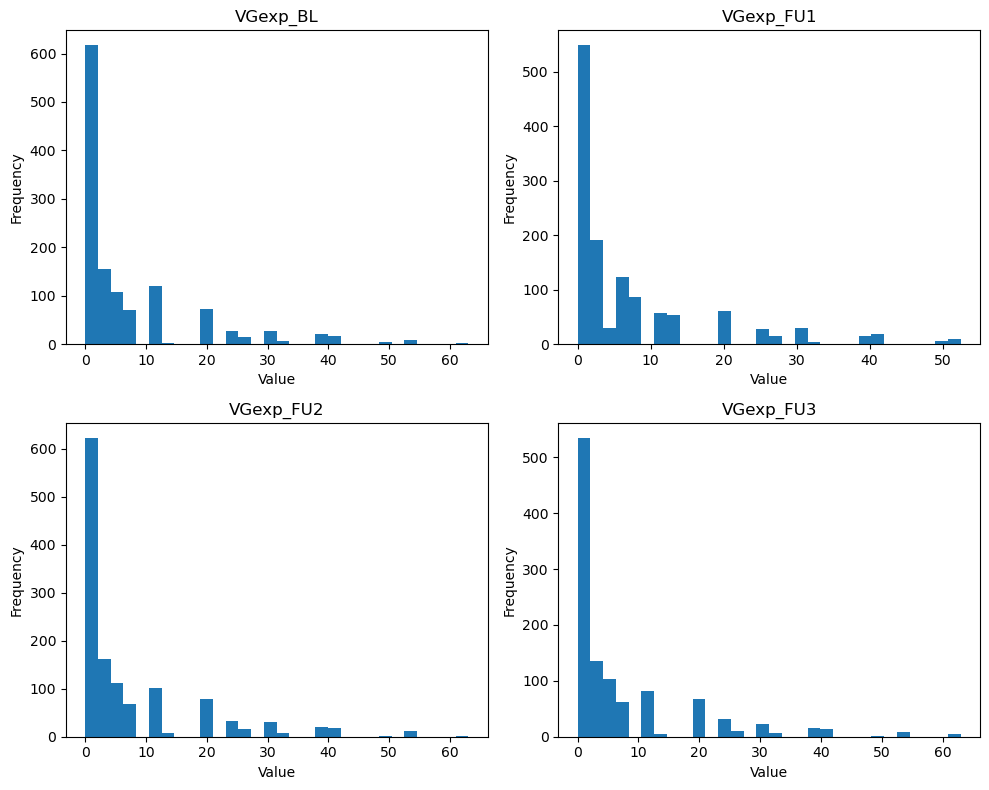

In [26]:
cols = ["VGexp_BL", "VGexp_FU1", "VGexp_FU2", "VGexp_FU3"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Use same binning across all for comparability
all_data = video_df[cols].values.flatten()
bins = 30  # or use: bins = np.histogram_bin_edges(all_data, bins=30)

for i, col in enumerate(cols):
    axes[i].hist(video_df[col].dropna(), bins=bins)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In order to do that, we will treat it as a two-part variable. The binary part will be video gaming participation, and will separate gamers from non-gamers based on whether they reported any gaming during the study period. The continuous part will capture video gaming exposure:

In [28]:
cols = ["VGexp_BL", "VGexp_FU1", "VGexp_FU2", "VGexp_FU3"]

perso_df["VG_gr"] = (
    video_df[cols]
    .fillna(0)        # treat NA as 0
    .ne(0)            # True where value != 0
    .any(axis=1)      # True if any column is non-zero
    .astype(int)      # convert True/False → 1/0
)
personality_df["VG_gr"] = (
    video_df[cols]
    .fillna(0)        # treat NA as 0
    .ne(0)            # True where value != 0
    .any(axis=1)      # True if any column is non-zero
    .astype(int)      # convert True/False → 1/0
)
perso_df["VG_gr"].value_counts()

VG_gr
1    1058
0     450
Name: count, dtype: int64

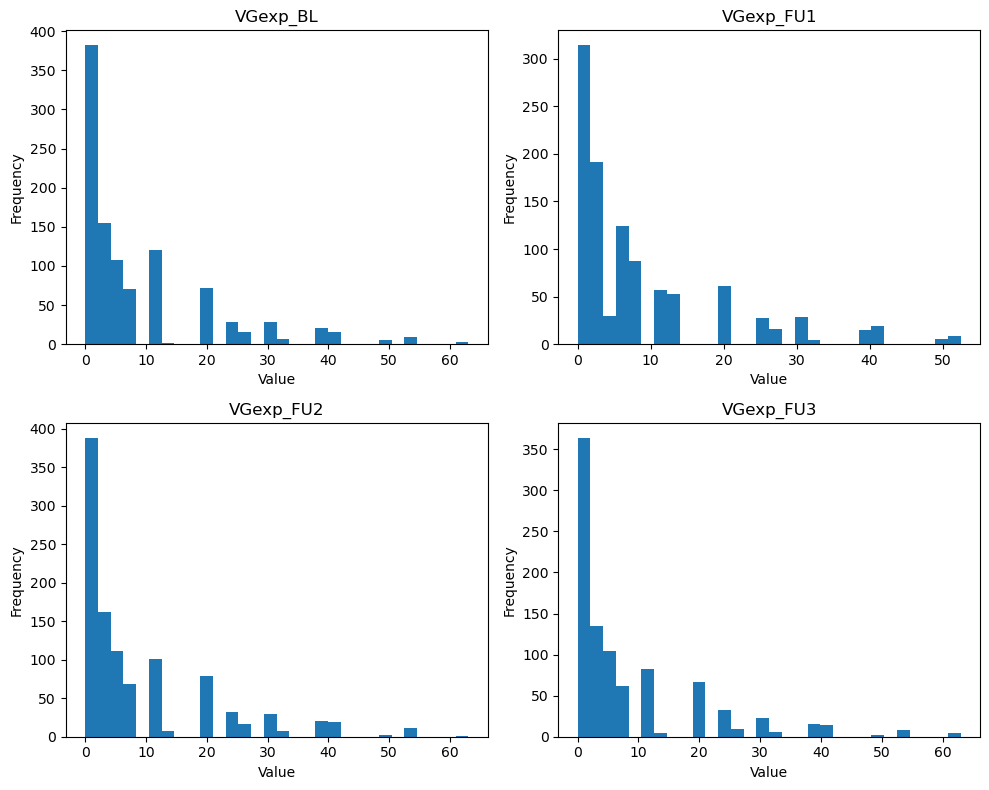

In [29]:
cols = ["VGexp_BL", "VGexp_FU1", "VGexp_FU2", "VGexp_FU3"]

df_merged = video_df.join(perso_df["VG_gr"])
df_sub = df_merged[df_merged["VG_gr"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

all_data = df_sub[cols].values.flatten()
bins = 30

for i, col in enumerate(cols):
    axes[i].hist(df_sub[col].dropna(), bins=bins)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

We finally observe the log-transformed distributions, as they substantially reduce skewness.

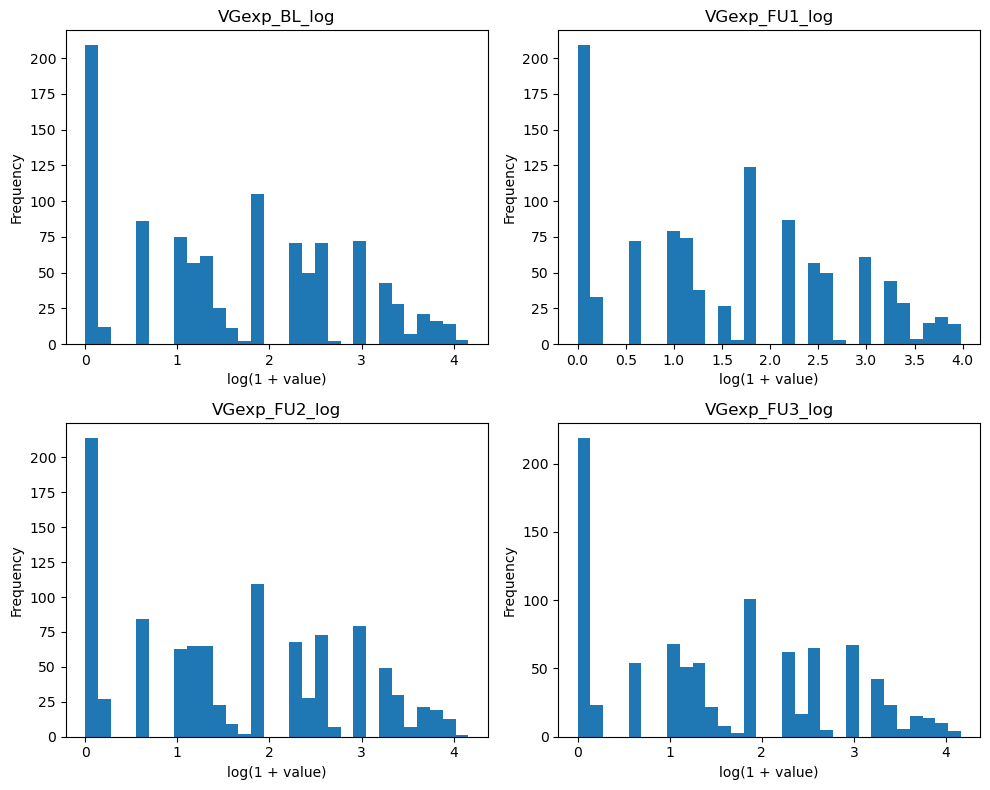

In [31]:
df_sub = df_sub.copy()

for col in cols:
    df_sub[col + "_log"] = np.log1p(df_sub[col])
# Log-transform (robust to zeros)
for col in cols:
    df_sub[col + "_log"] = np.log1p(df_sub[col])

log_cols = [c + "_log" for c in cols]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Consistent bins across transformed data
all_data = df_sub[log_cols].values.flatten()
bins = 30

for i, col in enumerate(log_cols):
    axes[i].hist(df_sub[col].dropna(), bins=bins)
    axes[i].set_title(col)
    axes[i].set_xlabel("log(1 + value)")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Although the variable is still zero-inflated, it is way more similar to a gaussian distribution now. These transformations might be useful for the model's implementation.

## Missingness

A systematic evaluation of missingness is essential to ensure the validity of longitudinal inferences and the appropriateness of the chosen estimation strategy. Beyond quantifying the overall proportion of missing data, it is necessary to examine its structure across waves, variables, and individuals.

Regarding the missing data handling, mean imputation and similar ad hoc methods (e.g., last observation carried forward) are fundamentally incompatible with the logic of a Random Intercept Cross-Lagged Panel Model (RI-CLPM), particularly because they distort the within-person variance, which is the core signal in these models. RI-CLPMs explicitly decompose observed scores into stable between-person differences (random intercepts) and within-person fluctuations over time; mean imputation artificially shrinks variability by replacing missing values with a constant, thereby attenuating within-person deviations and biasing autoregressive and cross-lagged parameters toward zero. More generally, inappropriate handling of missing data leads to biased estimates depending on the missingness mechanism, as data has to be Missing Completely At Random (MCAR) to apply this transformation.

- Under MCAR, the probability of missingness is unrelated to any observed or unobserved data, a highly restrictive and rarely met condition under which even listwise deletion is unbiased (though inefficient). 
- Under Missing At Random (MAR), the probability of missingness may depend on observed variables but not on unobserved values; this is the key assumption under which modern methods such as Full Information Maximum Likelihood (FIML) yield unbiased parameter estimates.
- In contrast, Missing Not At Random (MNAR) occurs when missingness depends on unobserved values themselves (e.g., individuals with high gaming drop out because of their gaming), in which case standard methods like FIML may still be biased unless the missingness process is explicitly modeled.

FIML operates by estimating model parameters directly from all available data points, maximizing the likelihood for each individual based on their observed data without imputing values, thereby preserving the covariance structure and, crucially, the within-person dynamics central to RI-CLPMs without losing any data points.

### Missing Values

In the following outputs, we will report the amount of missing values existing in each of the variables per wave.

First for personality traits:

In [40]:
missing_count = perso_df.isna().sum()
missing_percent = (perso_df.isna().sum() / len(perso_df)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

         missing_count  missing_percent
N_FU3              396        26.259947
IMP_FU3            394        26.127321
C_FU3              394        26.127321
AS_FU3             393        26.061008
E_FU3              393        26.061008
O_FU3              393        26.061008
H_FU3              392        25.994695
A_FU3              391        25.928382
SS_FU3             390        25.862069
O_FU2              237        15.716180
SS_FU2             231        15.318302
C_FU2              230        15.251989
A_FU2              228        15.119363
N_FU2              226        14.986737
AS_FU2             226        14.986737
E_FU2              225        14.920424
H_FU2              225        14.920424
IMP_FU2            218        14.456233
C_FU1              124         8.222812
SS_FU1             124         8.222812
H_FU1              123         8.156499
N_FU1              123         8.156499
IMP_FU1            122         8.090186
E_FU1              121         8.023873


And then for video gaming:

In [42]:
# Masks for eligible participants
mask_fu2 = video_igd["VG_gr_FU2"] == 1
mask_fu3 = video_igd["VG_gr_FU3"] == 1

# Split columns by wave
fu2_cols = [col for col in video_igd.columns if col.endswith("_FU2")]
fu3_cols = [col for col in video_igd.columns if col.endswith("_FU3")]

# Missing values FU2 (only those who took FU2)
missing_count_fu2 = video_igd.loc[mask_fu2, fu2_cols].isna().sum()
missing_percent_fu2 = (missing_count_fu2 / mask_fu2.sum()) * 100

# Missing values FU3 (only those who took FU3)
missing_count_fu3 = video_igd.loc[mask_fu3, fu3_cols].isna().sum()
missing_percent_fu3 = (missing_count_fu3 / mask_fu3.sum()) * 100

# Combine
missing_summary = pd.DataFrame({
    'missing_count': pd.concat([missing_count_fu2, missing_count_fu3]),
    'missing_percent': pd.concat([missing_percent_fu2, missing_percent_fu3])
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

                missing_count  missing_percent
VGigd_func_FU2            841        99.526627
VGigd5_FU2                 15         1.775148
VGigd10_FU2                14         1.656805
VGigd2_FU3                 12         1.648352
VGigd1_FU3                 11         1.510989
VGigd9_FU3                 11         1.510989
VGigd8_FU2                 12         1.420118
VGigd6_FU3                 10         1.373626
VGigd3_FU2                 11         1.301775
VGigd6_FU2                 11         1.301775
VGigd8_FU3                  9         1.236264
VGigd7_FU3                  9         1.236264
VGigd9_FU2                 10         1.183432
VGigd3_FU3                  8         1.098901
VGigd10_FU3                 7         0.961538
VGigd4_FU2                  7         0.828402
VGigd5_FU3                  6         0.824176
VGigd1_FU2                  6         0.710059
VGigd2_FU2                  6         0.710059
VGigd8a_FU2                 5         0.591716
VGigd7_FU2   

In [43]:
# Missing values genre
# Masks for eligible participants
mask_fu2 = video_prof["VG_gr_FU2"] == 1
mask_fu3 = video_prof["VG_gr_FU3"] == 1

# Split columns by wave
fu2_cols = [col for col in video_prof.columns if col.endswith("_FU2")]
fu3_cols = [col for col in video_prof.columns if col.endswith("_FU3")]

# Missing values FU2 (only those who took FU2)
missing_count_fu2 = video_prof.loc[mask_fu2, fu2_cols].isna().sum()
missing_percent_fu2 = (missing_count_fu2 / mask_fu2.sum()) * 100

# Missing values FU3 (only those who took FU3)
missing_count_fu3 = video_prof.loc[mask_fu3, fu3_cols].isna().sum()
missing_percent_fu3 = (missing_count_fu3 / mask_fu3.sum()) * 100

# Combine
missing_summary = pd.DataFrame({
    'missing_count': pd.concat([missing_count_fu2, missing_count_fu3]),
    'missing_percent': pd.concat([missing_percent_fu2, missing_percent_fu3])
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

               missing_count  missing_percent
VGonset_FU2               10         1.183432
VGm_novel_FU3              8         1.098901
VGm_fear_FU2               9         1.065089
VGm_care_FU3               7         0.961538
VGm_sad_FU2                8         0.946746
VGm_aggr_FU2               6         0.710059
VGm_care_FU2               6         0.710059
VGm_aggr_FU3               5         0.686813
VGm_fear_FU3               5         0.686813
VGm_play_FU3               5         0.686813
VGm_play_FU2               5         0.591716
VGm_sad_FU3                4         0.549451
VGm_novel_FU2              4         0.473373
VG_gr_FU2                  0         0.000000
VG_gr_FU3                  0         0.000000


### Retention rates

In a four-wave framework, retention reflects the extent to which participants are consistently followed across subsequent waves. High retention rates enhance internal validity by preserving sample comparability over time, whereas differential dropout can threaten both representativeness and statistical power.

In [46]:
def coverage_trait(df, trait, labels=None):
    """
    df: DataFrame (e.g., NEO_df)
    trait: str, e.g. 'neur', 'extr', 'open', 'agre', 'cons'
    labels: optional list of names for display (e.g., ['BL','FU1','FU2','FU3'])
    """
    
    # Build column names
    cols = [
        f"{trait}_BL",
        f"{trait}_FU1",
        f"{trait}_FU2",
        f"{trait}_FU3"
    ]
    
    data = df[cols]
    n = len(data)
    
    # Compute coverage matrix
    cov = pd.DataFrame(index=cols, columns=cols, dtype=float)
    
    for i in cols:
        for j in cols:
            cov.loc[i, j] = data[[i, j]].dropna().shape[0] / n
    
    if labels:
        cov.index = labels
        cov.columns = labels
    return cov.round(3)

def complete_case_percentage(df, trait, as_percent=False):
    """
    Returns the proportion (or percentage) of rows with complete data
    across BL, FU1, FU2, FU3 for a given trait.

    Parameters
    ----------
    df : pandas DataFrame
    trait : str
        e.g. 'N', 'E', 'O', etc.
    as_percent : bool (default=False)
        If True, returns percentage (0–100). Otherwise proportion (0–1).

    Returns
    -------
    float
    """
    
    cols = [
        f"{trait}_BL",
        f"{trait}_FU1",
        f"{trait}_FU2",
        f"{trait}_FU3"
    ]
    
    proportion = df[cols].notna().all(axis=1).mean()
    
    if as_percent:
        return proportion * 100
    
    return proportion

def report_trait_coverage(df, traits, labels=None):
    """
    Prints coverage matrix and complete-case percentage for each trait.
    
    Parameters
    ----------
    df : pandas DataFrame
    traits : list of str
        e.g. ['neur', 'extr', 'open', 'agre', 'cons']
    labels : list of str, optional
        Labels for BL, FU1, FU2, FU3
    """
    
    for trait in traits:
        print(f"\n=== Trait: {trait.upper()} ===")
        
        # Coverage matrix
        cov = coverage_trait(df, trait, labels=labels)
        print("\nPairwise coverage (proportion of available data):")
        print(cov)
        
        # Complete-case percentage
        cc = complete_case_percentage(df, trait, as_percent=True)
        print(f"\nComplete-case sample (BL + FU1 + FU2 + FU3): {cc:.2f}%")
        
        print("\n" + "-"*50)

In [47]:
traits = ["N", "E", "O", "A", "C","H","AS","IMP","SS"]

report_trait_coverage(
    perso_df,
    traits,
    labels=["BL", "FU1", "FU2", "FU3"]
)


=== Trait: N ===

Pairwise coverage (proportion of available data):
        BL    FU1    FU2    FU3
BL   0.991  0.909  0.843  0.731
FU1  0.909  0.918  0.840  0.728
FU2  0.843  0.840  0.850  0.731
FU3  0.731  0.728  0.731  0.737

Complete-case sample (BL + FU1 + FU2 + FU3): 71.62%

--------------------------------------------------

=== Trait: E ===

Pairwise coverage (proportion of available data):
        BL    FU1    FU2    FU3
BL   0.989  0.910  0.842  0.731
FU1  0.910  0.920  0.842  0.731
FU2  0.842  0.842  0.851  0.733
FU3  0.731  0.731  0.733  0.739

Complete-case sample (BL + FU1 + FU2 + FU3): 71.82%

--------------------------------------------------

=== Trait: O ===

Pairwise coverage (proportion of available data):
        BL    FU1    FU2    FU3
BL   0.990  0.912  0.835  0.732
FU1  0.912  0.922  0.836  0.733
FU2  0.835  0.836  0.843  0.727
FU3  0.732  0.733  0.727  0.739

Complete-case sample (BL + FU1 + FU2 + FU3): 71.35%

-------------------------------------------------

In [48]:
cols = ['N_BL', 'E_BL', 'O_BL', 'A_BL', 'C_BL']

# rows with at least one NA in those columns
na_rows = personality_df[personality_df[cols].isna().any(axis=1)]

# number of such rows
n_na = len(na_rows)

print("Number of rows with NA:", n_na)

Number of rows with NA: 74


In [49]:
ids = na_rows['Ligne']

meta_subset = meta_df[meta_df['Ligne'].isin(ids)]
meta_subset.head(8)

,Ligne,Language de BL,ImagingCentreID,gender de D_BL
4,5,English,Centre_C,1.0
10,11,German,Centre_H,2.0
25,26,German,Centre_C,1.0
30,31,French,Centre_G,1.0
48,49,French,Centre_C,1.0
78,79,English,Centre_G,2.0
80,81,English,Centre_H,1.0
96,97,German,Centre_B,2.0


We observe the retention rates also for the video gaming questionnaire:

In [51]:
n = video_df.shape[0]

fu2 = video_df["VG_gr_FU2"].notna()
fu3 = video_df["VG_gr_FU3"].notna()

print(
    "FU2 missing:", fu2.eq(False).sum(), "- Percentage:", (fu2.eq(False).sum()/n*100).round(2), "%\n",
    "FU3 missing:", fu3.eq(False).sum(), "- Percentage:", (fu3.eq(False).sum()/n*100).round(2), "%\n",
    "Took both FU2 & FU3:", (fu2 & fu3).sum(), "- Percentage:", ((fu2 & fu3).sum()/n*100).round(2), "%\n",
    "Took neither:", (~fu2 & ~fu3).sum(), "- Percentage:", ((~fu2 & ~fu3).sum()/n*100).round(2), "%\n",
    "Only FU2:", (fu2 & ~fu3).sum(), "- Percentage:", ((fu2 & ~fu3).sum()/n*100).round(2), "%\n",
    "Only FU3:", (~fu2 & fu3).sum(), "- Percentage:", ((~fu2 & fu3).sum()/n*100).round(2), "%"
)

FU2 missing: 219 - Percentage: 14.52 %
 FU3 missing: 390 - Percentage: 25.86 %
 Took both FU2 & FU3: 1114 - Percentage: 73.87 %
 Took neither: 215 - Percentage: 14.26 %
 Only FU2: 175 - Percentage: 11.6 %
 Only FU3: 4 - Percentage: 0.27 %


As the questions for gaming motivations, genre preference and video gaming addiction were only taken by those participants who were currently playing video games, we report the sample sizes:

In [53]:
mask_fu2 = video_df["VG_gr_FU2"] == 1
mask_fu3 = video_df["VG_gr_FU3"] == 1
gamers_FU2= video_df[mask_fu2]
gamers_FU3=video_df[mask_fu3]

In [54]:
print("FU2 gamers", gamers_FU2.shape[0],"- Percentage:",fu2.eq(False).sum()/video_df.shape[0]*100,"%\n",
    "FU3 gamers", gamers_FU3.shape[0],"- Percentage:",fu3.eq(False).sum()/video_df.shape[0]*100,"%")

FU2 gamers 845 - Percentage: 14.522546419098143 %
 FU3 gamers 728 - Percentage: 25.862068965517242 %


### Missingness structure

Prior to implementing FIML estimation, the missing data mechanism was formally assessed across all variables of interest using tests of MCAR (Little's MCAR test). Establishing whether the MCAR assumption holds is critical, as it informs the appropriateness and interpretability of model-based handling of incomplete data. In cases where the MCAR hypothesis was rejected, the missingness mechanism was conservatively treated as Missing at Random (MAR), acknowledging that the probability of missingness may depend on observed data but not on unobserved values. Under this assumption, Full Information Maximum Likelihood remains a robust and efficient approach.

In [57]:
def mcar_test_trait(df, trait):    
    cols = [
        f"{trait}_BL",
        f"{trait}_FU1",
        f"{trait}_FU2",
        f"{trait}_FU3"
    ]
    
    test = MCARTest(method="little")
    result = test(df[cols])
    
    print(f"\n=== MCAR Test for {trait.upper()} ===")
    print(result)

traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
for trait in traits:
    mcar_test_trait(perso_df, trait)


=== MCAR Test for N ===
0.5401399752022107

=== MCAR Test for E ===
0.09761221945174059

=== MCAR Test for O ===
0.20412166911925322

=== MCAR Test for A ===
0.4806814618127323

=== MCAR Test for C ===
0.016648467481343965

=== MCAR Test for H ===
0.9486022707148047

=== MCAR Test for AS ===
0.47005364890124623

=== MCAR Test for IMP ===
0.30634284744968765

=== MCAR Test for SS ===
0.024388717896178025


In [58]:
def mcar_test_vgexp(df):
    cols = [
        "VGexp_act_FU2",
        "VGexp_act_FU3"
    ]
    
    test = MCARTest(method="little")
    result = test(df[cols])
    
    print("\n=== MCAR Test for VGexp_act ===")
    print(result)

mcar_test_vgexp(video_df)


=== MCAR Test for VGexp_act ===
0.7522050233755598


In [59]:
traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
waves = ["BL", "FU1", "FU2", "FU3"]

df = perso_df.copy()

# Create missingness indicators
for trait in traits:
    for wave in waves:
        col = f"{trait}_{wave}"
        r_col = f"R_{trait}_{wave}"
        df[r_col] = df[col].notna().astype(int)

In [60]:
def test_mar_trait(df, trait):
    print(f"\n=== MAR Test for {trait} ===")
    
    # Define time structure
    time_pairs = [
        ("BL", "FU1"),
        ("FU1", "FU2"),
        ("FU2", "FU3")
    ]
    
    for t_prev, t_curr in time_pairs:
        y = df[f"R_{trait}_{t_curr}"]  # missingness indicator
        
        X = pd.DataFrame({
            f"{trait}_{t_prev}": df[f"{trait}_{t_prev}"]
        })
        
        # Drop rows with missing predictors
        valid = X.notna().all(axis=1)
        X = X[valid]
        y = y[valid]
        
        X = sm.add_constant(X)
        
        model = sm.Logit(y, X).fit(disp=0)
        
        print(f"\nPredicting R_{trait}_{t_curr} from {trait}_{t_prev}")
        print(model.summary())

In [61]:
for trait in traits:
    test_mar_trait(df, trait)


=== MAR Test for N ===

Predicting R_N_FU1 from N_BL
                           Logit Regression Results                           
Dep. Variable:                R_N_FU1   No. Observations:                 1494
Model:                          Logit   Df Residuals:                     1492
Method:                           MLE   Df Model:                            1
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                0.001257
Time:                        11:36:39   Log-Likelihood:                -424.39
converged:                       True   LL-Null:                       -424.93
Covariance Type:            nonrobust   LLR p-value:                    0.3013
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0803      0.330      6.307      0.000       1.434       2.727
N_BL           0.1879      0.182      1.034      0.301      -0.168       0.54

## Outliers

Outlier detection is a critical component of data quality control in longitudinal analyses, as atypical observations can disproportionately influence parameter estimates, distort distributions, and compromise model assumptions. Cross-sectional outliers—extreme values observed within a single wave—may reflect measurement error, data entry issues, or genuinely rare cases. Identifying these observations at each time point helps ensure that the observed distributions are credible and that subsequent analyses are not unduly driven by anomalous data points.

In addition, change outliers—unusually large deviations in an individual’s trajectory between waves—are particularly salient in longitudinal designs. These cases may indicate inconsistencies in measurement, transient external influences, or violations of assumed developmental or temporal patterns. Failure to account for such irregular changes can bias estimates of within-person effects and growth parameters. This section therefore evaluates both cross-sectional and change outliers to distinguish between plausible variability and data artifacts, ensuring the robustness and interpretability of longitudinal inferences.

In this study, only extreme outliers (+3SD or -3SD) were considered for exclusion, as there is no convention on the extent of impossible change.

### Cross-sectional outliers

We first take a look on the extreme outliers in the personality measurements in each of the time points:

In [67]:
perso_df = perso_df.loc[:, perso_df.columns != "Ligne"]
numeric_cols = perso_df.select_dtypes(include=['int64', 'float64']).columns

outlier_mask = pd.Series(False, index=perso_df.index)
outlier_counts = {}

for col in numeric_cols:
    X = perso_df[col].mean()
    SD = perso_df[col].std()
    
    lower = X - 3 * SD
    upper = X + 3 * SD
    
    col_outliers = (perso_df[col] < lower) | (perso_df[col] > upper)
    
    outlier_mask = outlier_mask | col_outliers
    outlier_counts[col] = col_outliers.sum() 


outliers_df = perso_df[outlier_mask]

# Summary table
outlier_summary = pd.DataFrame.from_dict(
    outlier_counts, orient='index', columns=['n_outliers']
).sort_values(by='n_outliers', ascending=False)


print("Total rows with at least one outlier:", len(outliers_df))
print("\nOutliers per column:")
print(outlier_summary)

Total rows with at least one outlier: 66

Outliers per column:
         n_outliers
N_FU2             8
C_FU1             7
N_FU1             6
N_BL              5
H_BL              4
N_FU3             4
SS_FU1            4
H_FU2             4
E_FU1             4
AS_FU2            3
C_FU2             3
SS_BL             3
C_FU3             3
O_FU1             3
A_FU2             3
C_BL              3
O_FU2             3
AS_FU3            2
IMP_FU2           2
E_BL              2
IMP_FU3           2
AS_BL             2
IMP_BL            2
E_FU2             2
H_FU1             2
SS_FU2            1
A_FU3             1
AS_FU1            1
A_BL              1
O_BL              1
SS_FU3            1
IMP_FU1           0
O_FU3             0
E_FU3             0
A_FU1             0
H_FU3             0


In [68]:
perso_df["outlier"] = outlier_mask.astype(int)

We can visualize them better using boxplots. Note that the measures from SURPS have a scale of 1-4 instead of 0-4:

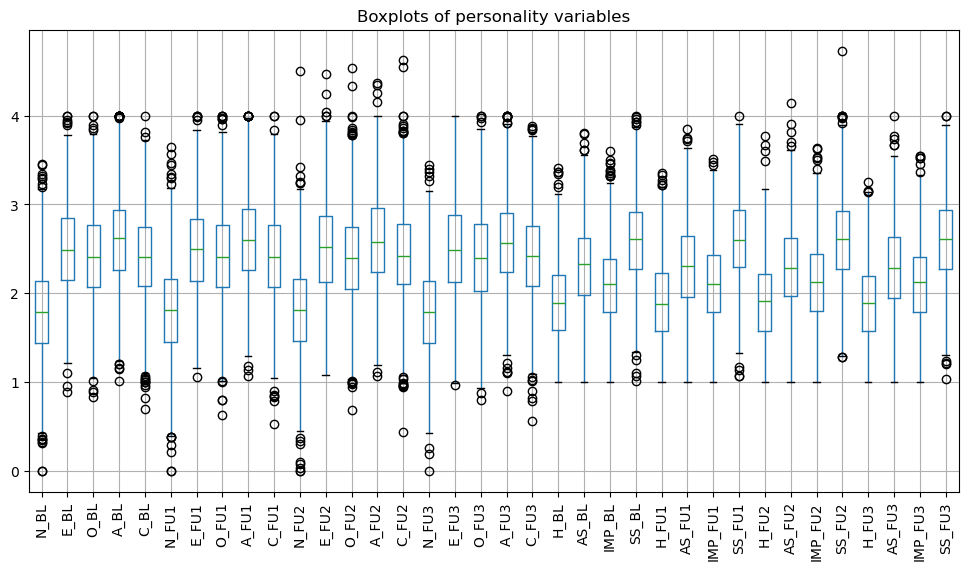

In [70]:
perso_df[numeric_cols].boxplot(figsize=(12, 6), rot=90)
plt.title("Boxplots of personality variables")
plt.show()

We do the same for video gaming experience:

In [72]:
# Select only VGexp columns
vgexp_cols = video_df[["VGexp_BL", "VGexp_FU1", "VGexp_FU2", "VGexp_FU3"]]

outlier_mask = pd.Series(False, index=video_df.index)
outlier_counts = {}

for col in vgexp_cols:
    X = video_df[col].median()
    SD = video_df[col].std()
    
    lower = X - 3 * SD
    upper = X + 3 * SD
    
    col_outliers = (video_df[col] < lower) | (video_df[col] > upper)
    
    outlier_mask = outlier_mask | col_outliers
    outlier_counts[col] = col_outliers.sum()

# Rows with at least one VGexp outlier
vgexp_outliers_df = video_df[outlier_mask]

# Summary
vgexp_outlier_summary = pd.DataFrame.from_dict(
    outlier_counts, orient='index', columns=['n_outliers']
).sort_values(by='n_outliers', ascending=False)

print("Total rows with VGexp outliers:", len(vgexp_outliers_df))
print("\nVGexp outliers per column:")
print(vgexp_outlier_summary)

Total rows with VGexp outliers: 186

VGexp outliers per column:
           n_outliers
VGexp_BL           54
VGexp_FU2          54
VGexp_FU1          48
VGexp_FU3          43


### Longitudinal outliers

Outliers analysis in personality traits' change is especially important, as personality traits are supposed to be largely stable, so we should distrust any abrupt personality jump between assessments. We therefore inspect the outliers in the substraction in personality scores between time points.

In [76]:
df_change = pd.DataFrame()
traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
for trait in traits:
    df_change[f"{trait}_BL_FU1"] = perso_df[f"{trait}_FU1"] - perso_df[f"{trait}_BL"]
    df_change[f"{trait}_FU1_FU2"] = perso_df[f"{trait}_FU2"] - perso_df[f"{trait}_FU1"]
    df_change[f"{trait}_FU2_FU3"] = perso_df[f"{trait}_FU3"] - perso_df[f"{trait}_FU2"]

In [77]:
import pandas as pd

# Initialize
outlier_mask = pd.Series(False, index=df_change.index)

upper_counts = {}
lower_counts = {}
total_counts = {}

# Loop through columns
for col in df_change.columns:
    X = df_change[col].mean()
    SD = df_change[col].std()
    
    lower = X - 3 * SD
    upper = X + 3 * SD
    
    lower_outliers = df_change[col] < lower
    upper_outliers = df_change[col] > upper
    
    col_outliers = lower_outliers | upper_outliers
    
    # Track rows with any outlier
    outlier_mask = outlier_mask | col_outliers
    
    # Store counts
    lower_counts[col] = lower_outliers.sum()
    upper_counts[col] = upper_outliers.sum()
    total_counts[col] = col_outliers.sum()

# Rows with at least one outlier
change_outliers_df = df_change[outlier_mask]

# Create summary table
summary_df = pd.DataFrame({
    'lower_outliers': lower_counts,
    'upper_outliers': upper_counts,
    'this total': total_counts
}).sort_values(by='this total', ascending=False)


print(summary_df)


print("\nTotals:")
print("Total lower outliers:", summary_df['lower_outliers'].sum())
print("Total upper outliers:", summary_df['upper_outliers'].sum())
print("Total overall:", summary_df['this total'].sum())


print("\nNumber of participants with at least one outlier:", len(change_outliers_df))

             lower_outliers  upper_outliers  this total
C_FU1_FU2                 4               5           9
E_FU1_FU2                 1               6           7
SS_FU1_FU2                1               6           7
SS_FU2_FU3                6               1           7
E_BL_FU1                  4               3           7
O_FU1_FU2                 1               5           6
A_FU1_FU2                 2               4           6
AS_FU1_FU2                1               5           6
H_FU2_FU3                 4               1           5
IMP_FU1_FU2               1               4           5
A_BL_FU1                  2               3           5
AS_FU2_FU3                3               2           5
C_FU2_FU3                 3               2           5
H_FU1_FU2                 2               3           5
IMP_FU2_FU3               3               1           4
IMP_BL_FU1                2               2           4
AS_BL_FU1                 2               2     

The outliers for the change in video gaming measures is not interesting, as sudden changes in video gaming behavior are possible.

### Outlier characteristics

First, we want to know if the outliers in personality measures are different in terms of video gaming engagement than non-outliers. We create contingency tables, both for outlier counts and for proportions within each group (fixes uniqual sample sizes):

In [81]:
ct = pd.crosstab(perso_df["outlier"], perso_df["VG_gr"])
print(ct)

VG_gr      0     1
outlier           
0        436  1006
1         14    52


In [82]:
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print(ct_prop)

VG_gr           0         1
outlier                    
0        0.302358  0.697642
1        0.212121  0.787879


We use a chi-squared test of independence to evaluate whether the distribution of gaming status differs across outlier groups, because both variables are categorical and the test compares proportions across groups while accounting for unequal sample sizes:

In [84]:
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi2:", chi2)
print("p-value:", p)

Chi2: 2.0424954538361417
p-value: 0.15295853824039915


We use logistic regression to contrast the findings:

In [86]:
X = sm.add_constant(perso_df["outlier"])
y = perso_df["VG_gr"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.608643
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  VG_gr   No. Observations:                 1508
Model:                          Logit   Df Residuals:                     1506
Method:                           MLE   Df Model:                            1
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                0.001422
Time:                        11:36:45   Log-Likelihood:                -917.83
converged:                       True   LL-Null:                       -919.14
Covariance Type:            nonrobust   LLR p-value:                    0.1059
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8361      0.057     14.582      0.000       0.724       0.948
outlier        0.4761      0.

Second, we would like to know if those people that are outliers have consistent measures across the rest of waves. We will do this by making sure that they at least stay in the same pole of the construct. Those that change polarization will be treated as error outliers.

In [88]:
# Define constructs and relevant columns

constructs = ["N", "E", "A", "C", "O", "H", "AS", "IMP", "SS"]

construct_cols = [
    col for col in perso_df.columns
    if any(col.startswith(cons + "_") for cons in constructs)
]


#Z-standardize those columns

z_df = perso_df.copy()

for col in construct_cols:
    z_df[col] = (perso_df[col] - perso_df[col].mean()) / perso_df[col].std()


# Detect outliers (in z-space)

outlier_mask = z_df[construct_cols].abs() > 3


# Consistency rule (robust version)

perso_df["outlier_consistent"] = pd.Series(
    pd.NA, index=perso_df.index, dtype="boolean"
)

for cons in constructs:
    cols = [c for c in construct_cols if c.startswith(cons + "_")]

    if len(cols) < 2:
        continue

    for i in z_df.index:
        row = z_df.loc[i, cols]
        outliers = outlier_mask.loc[i, cols]

        # Skip if no outliers in this construct
        if not outliers.any():
            continue

        outlier_values = row[outliers].dropna()

        # If no valid outlier values, skip
        if len(outlier_values) == 0:
            continue


        # Check internal consistency among outliers
        
        if (outlier_values > 0).all():
            direction = 1
        elif (outlier_values < 0).all():
            direction = -1
        else:
            consistent_all = False
            # update and continue
            if pd.isna(perso_df.loc[i, "outlier_consistent"]):
                perso_df.loc[i, "outlier_consistent"] = False
            else:
                perso_df.loc[i, "outlier_consistent"] = (
                    perso_df.loc[i, "outlier_consistent"] and False
                )
            continue

      
        # Compare with non-outliers
      
        others = row[~outliers].dropna()

        if len(others) == 0:
            consistent_all = True
        else:
            if direction == 1:
                consistent_all = (others > 0).all()
            else:
                consistent_all = (others < 0).all()


        # 3. Aggregate across constructs

        if pd.isna(perso_df.loc[i, "outlier_consistent"]):
            perso_df.loc[i, "outlier_consistent"] = consistent_all
        else:
            perso_df.loc[i, "outlier_consistent"] = (
                perso_df.loc[i, "outlier_consistent"] and consistent_all
            )

# Inspect results
print(perso_df["outlier_consistent"].value_counts(dropna=False))

outlier_consistent
<NA>     1442
True       64
False       2
Name: count, dtype: Int64


In [89]:
# Inspect inconsistent cases

# rows where inconsistency was detected
inconsistent_idx = perso_df.index[perso_df["outlier_consistent"] == False]

for i in inconsistent_idx:
    print(f"\n=== Row {i} ===")

    for cons in constructs:
        cols = [c for c in construct_cols if c.startswith(cons + "_")]
        if len(cols) < 2:
            continue

        row_z = z_df.loc[i, cols]
        row_outliers = outlier_mask.loc[i, cols]

        # only inspect constructs where there is at least one outlier
        if not row_outliers.any():
            continue

        print(f"\nConstruct: {cons}")

        display_df = pd.DataFrame({
            "z_score": row_z,
            "is_outlier": row_outliers,
            "sign": row_z.apply(lambda x: "+" if x > 0 else "-" if x < 0 else "0")
        })

        print(display_df)


=== Row 140 ===

Construct: N
        z_score  is_outlier sign
N_BL   1.731818       False    +
N_FU1  0.966700       False    +
N_FU2  4.057172        True    +
N_FU3  0.843891       False    +

Construct: C
        z_score  is_outlier sign
C_BL   0.453034       False    +
C_FU1  1.692909       False    +
C_FU2  4.121898        True    +
C_FU3       NaN       False    0

Construct: H
        z_score  is_outlier sign
H_BL  -0.721636       False    -
H_FU1       NaN       False    0
H_FU2  3.388281        True    +
H_FU3 -0.334359       False    -

=== Row 1164 ===

Construct: E
        z_score  is_outlier sign
E_BL  -0.281230       False    -
E_FU1  1.144838       False    +
E_FU2  3.793845        True    +
E_FU3  1.220390       False    +

Construct: A
        z_score  is_outlier sign
A_BL   1.257748       False    +
A_FU1  1.772754       False    +
A_FU2  3.339683        True    +
A_FU3  1.490714       False    +

Construct: C
        z_score  is_outlier sign
C_BL   0.904403       F

## Within-person Variability

Assessing within-person variability is a prerequisite for valid within-person analyses in longitudinal designs. Such models rely on temporal fluctuations within individuals to estimate associations between variables over time. If a variable exhibits little or no within-person variation across waves, it becomes statistically uninformative for estimating within-person effects, as there is insufficient deviation from an individual’s own mean to model change or covariation. 

This section therefore evaluates the extent of within-person variability for each variable of interest across the four waves, ensuring that the data structure supports the identification of dynamic processes and that estimated effects are not driven solely by between-person differences.

### Change Plots

First we plot all the data and the between-person mean to get a grasp of the variability across time points for each of the different variables.

In [94]:
def spaghetti_plot(df, trait):

    # Construct column names dynamically
    cols = [
        f"{trait}_BL",
        f"{trait}_FU1",
        f"{trait}_FU2",
        f"{trait}_FU3"
    ]
    
    # Subset and rename
    data = df[cols].copy()
    data.columns = ["BL", "FU1", "FU2", "FU3"]
    data["subject"] = data.index
    
    # Long format
    df_long = data.melt(id_vars="subject",
                        var_name="time",
                        value_name=trait)
    
    # Individual trajectories
    for _, d in df_long.groupby("subject"):
        plt.plot(d["time"], d[trait], alpha=0.2)
    
    # Mean trajectory
    mean_traj = df_long.groupby("time")[trait].mean()
    plt.plot(
        mean_traj.index,
        mean_traj.values,
        linewidth=2,
        color="red",
        zorder=10,
        label="Mean"
    )
    
    plt.xlabel("Timepoint")
    plt.ylabel(f"{trait.capitalize()} Mean")
    plt.title(f"Spaghetti Plot of {trait.capitalize()} Across Time")
    plt.legend()

C:\Users\34645\AppData\Local\Temp\ipykernel_3388\1122862846.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\34645\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


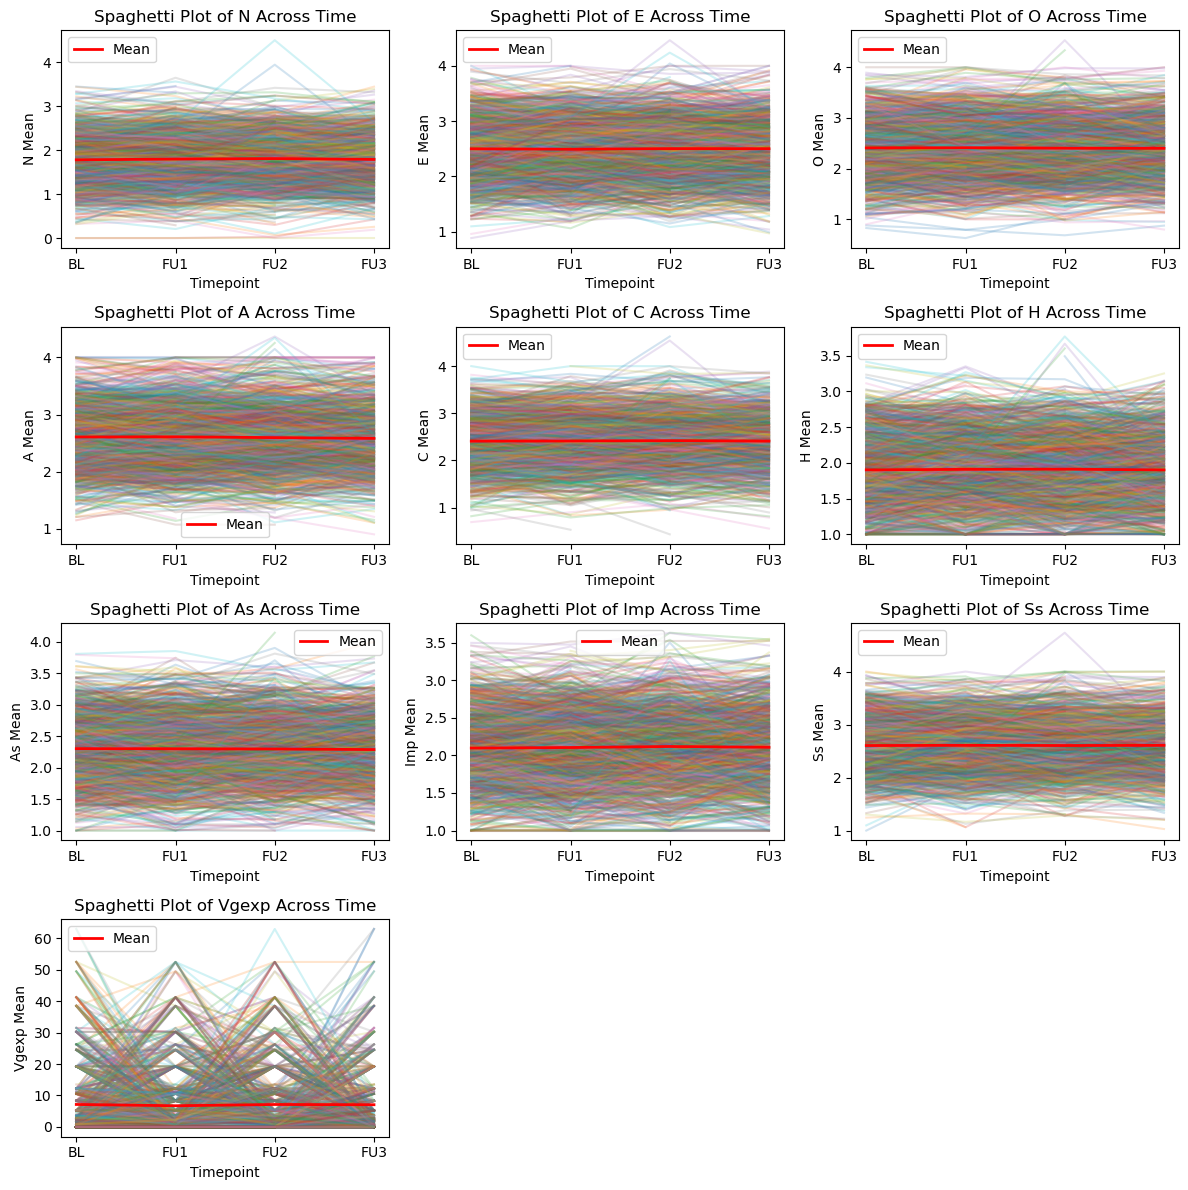

In [95]:
plt.figure(figsize=(12, 12))

plt.subplot(4, 3, 1)
spaghetti_plot(NEO_df, "N")

plt.subplot(4, 3, 2)
spaghetti_plot(NEO_df, "E")

plt.subplot(4, 3, 3)
spaghetti_plot(NEO_df, "O")

plt.subplot(4, 3, 4)
spaghetti_plot(NEO_df, "A")

plt.subplot(4, 3, 5)
spaghetti_plot(NEO_df, "C")

plt.subplot(4, 3, 6)
spaghetti_plot(SURPS_df, "H")

plt.subplot(4, 3, 7)
spaghetti_plot(SURPS_df, "AS")

plt.subplot(4, 3, 8)
spaghetti_plot(SURPS_df, "IMP")

plt.subplot(4, 3, 9)
spaghetti_plot(SURPS_df, "SS")

video_df["VGexp_BL"]=video_df["VGexp_5y_FU2"]
video_df["VGexp_FU1"]=video_df["VGexp_3y_FU2"]
video_df["VGexp_FU2"]=video_df["VGexp_act_FU2"]
video_df["VGexp_FU3"]=video_df["VGexp_act_FU3"]
plt.subplot(4,3,10)
spaghetti_plot(video_df, "VGexp")



plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

### Reliable Change Index

The Reliable Change Index (RCI) is employed to assess whether observed changes in individual scores across waves reflect statistically reliable change rather than measurement error. In longitudinal data, especially when evaluating within-person dynamics, it is insufficient to rely solely on raw score differences, as these may fall within the bounds of instrument unreliability. The RCI incorporates information on the scale’s reliability and standard error of measurement to determine whether the magnitude of change exceeds what would be expected by chance. 

This section applies the RCI to identify individuals exhibiting meaningful increases or decreases over time, thereby enhancing the interpretability of change patterns and supporting more rigorous conclusions about individual-level trajectories. Reliability scores were taken from *McCrae, R. R., & Costa Jr, P. T. (2004). A contemplated revision of the NEO Five-Factor Inventory. Personality and individual differences, 36(3), 587-596* for the Big Five and from *Fernández-Calderón, F., Díaz-Batanero, C., Rojas-Tejada, A. J., Castellanos-Ryan, N., & Lozano-Rojas, Ó. M. (2018). Adaptation to the Spanish population of the Substance Use Risk Profile Scale (SURPS) and psychometric properties. adicciones, 30(3), 208-218* for the SURPS. Note that calculating the RCI for video gaming does not make sense because video gaming is not a trait, but a behavior. Therefore temporal reliability does not apply.

In [98]:
def rci_any_change(df, trait, reliability, threshold=1.96):
    """
    Returns:
    - n_changed (any change)
    - percent_changed
    - boolean series (who changed)
    - table with pairwise counts and percentages
    """
    
    timepoints = ["BL", "FU1", "FU2", "FU3"]
    cols = {tp: f"{trait}_{tp}" for tp in timepoints}
    
    data = df[list(cols.values())].copy()
    
    # Baseline SD
    sd = data[cols["BL"]].std()
    se_diff = sd * np.sqrt(2 * (1 - reliability))
    
    any_change = pd.Series(False, index=data.index)
    
    pairs = list(itertools.combinations(timepoints, 2))
    
    results = []

    for t1, t2 in pairs:
        diff = data[cols[t2]] - data[cols[t1]]
        rci = diff / se_diff
        
        change = rci.abs() > threshold
        change = change.fillna(False)
        
        # Update global flag
        any_change = any_change | change
        
        # Store results
        n_pair = change.sum()
        pct_pair = (n_pair / len(change)) * 100
        
        results.append({
            "Comparison": f"{t1}-{t2}",
            "N_changed": n_pair,
            "Percent": pct_pair
        })
    
    # Overall
    n_changed = any_change.sum()
    percent = (n_changed / len(any_change)) * 100
    
    results_df = pd.DataFrame(results)
    
    return n_changed, percent, any_change, results_df

In [99]:
# We use test-retest reliabilities of the NEO-FFI (2 weeks) from McCrae & Costa (2004) on a sample of highschoolers.
# Ref. McCrae, R. R., & Costa Jr, P. T. (2004). A contemplated revision of the NEO Five-Factor Inventory. Personality and individual differences, 36(3), 587-596.

rel_cons = 0.87   # Conscientiousness
rel_neur = 0.88   # Neuroticism
rel_agre = 0.87   # Agreeableness
rel_extr = 0.87   # Extraversion
rel_open = 0.88   # Openness to Experience

# Update dictionary
rel = {
    "C": rel_cons,
    "N": rel_neur,
    "A": rel_agre,
    "E": rel_extr,
    "O": rel_open
}

for trait in ["N", "E", "O", "A", "C"]:
    
    n, pct, _, table = rci_any_change(NEO_df, trait, rel[trait])
    
    print(f"\n=== {trait.upper()} ===")
    print(f"{n} participants ({pct:.2f}%) showed change at least once\n")
    
    print(table.to_string(index=False))


=== N ===
524 participants (34.75%) showed change at least once

Comparison  N_changed   Percent
    BL-FU1        131  8.687003
    BL-FU2        193 12.798408
    BL-FU3        180 11.936340
   FU1-FU2        145  9.615385
   FU1-FU3        190 12.599469
   FU2-FU3        133  8.819629

=== E ===
508 participants (33.69%) showed change at least once

Comparison  N_changed   Percent
    BL-FU1        132  8.753316
    BL-FU2        187 12.400531
    BL-FU3        164 10.875332
   FU1-FU2        141  9.350133
   FU1-FU3        156 10.344828
   FU2-FU3        111  7.360743

=== O ===
505 participants (33.49%) showed change at least once

Comparison  N_changed   Percent
    BL-FU1        140  9.283820
    BL-FU2        172 11.405836
    BL-FU3        163 10.809019
   FU1-FU2        135  8.952255
   FU1-FU3        175 11.604775
   FU2-FU3        110  7.294430

=== A ===
521 participants (34.55%) showed change at least once

Comparison  N_changed   Percent
    BL-FU1        138  9.151194


In [100]:
# We use test-retest reliabilities of the SURPS (1 week) from Fernández-Calderón et al. (2004) on a sample of adults.
# Ref. Fernández-Calderón, F., Díaz-Batanero, C., Rojas-Tejada, A. J., Castellanos-Ryan, N., & Lozano-Rojas, Ó. M. (2018). Adaptation to the Spanish population of the Substance Use Risk Profile Scale (SURPS) and psychometric properties. adicciones, 30(3), 208-218.

rel_h = 0.755   # Hopelessness
rel_as = 0.793   # Anxiety Sensitivity
rel_imp = 0.733  # Impulsivity
rel_ss = 0.868   # Sensation Seeking

# Update dictionary
rel = {
    "H": rel_h,
    "AS": rel_as,
    "IMP": rel_imp,
    "SS": rel_ss,
}

for trait in ["H", "AS", "IMP", "SS"]:
    
    n, pct, _, table = rci_any_change(SURPS_df, trait, rel[trait])
    
    print(f"\n=== {trait.upper()} ===")
    print(f"{n} participants ({pct:.2f}%) showed change at least once\n")
    
    print(table.to_string(index=False))


=== H ===
264 participants (17.51%) showed change at least once

Comparison  N_changed  Percent
    BL-FU1         42 2.785146
    BL-FU2         97 6.432361
    BL-FU3         94 6.233422
   FU1-FU2         53 3.514589
   FU1-FU3         79 5.238727
   FU2-FU3         45 2.984085

=== AS ===
344 participants (22.81%) showed change at least once

Comparison  N_changed  Percent
    BL-FU1         57 3.779841
    BL-FU2        132 8.753316
    BL-FU3        115 7.625995
   FU1-FU2         84 5.570292
   FU1-FU3         92 6.100796
   FU2-FU3         57 3.779841

=== IMP ===
228 participants (15.12%) showed change at least once

Comparison  N_changed  Percent
    BL-FU1         41 2.718833
    BL-FU2         68 4.509284
    BL-FU3         74 4.907162
   FU1-FU2         40 2.652520
   FU1-FU3         70 4.641910
   FU2-FU3         33 2.188329

=== SS ===
572 participants (37.93%) showed change at least once

Comparison  N_changed   Percent
    BL-FU1        157 10.411141
    BL-FU2       

### Effect sizes

Effect size estimation using Cohen's d is incorporated to complement the interpretation of the RCI. While the RCI determines whether individual-level change exceeds measurement error, it does not convey the magnitude of that change in standardized terms. Cohen’s d addresses this limitation by quantifying the size of change relative to the variability in the data, thereby facilitating interpretation of practical or clinical significance. This section reports effect sizes alongside RCI classifications to provide a more comprehensive assessment of change, distinguishing not only whether change is reliable, but also whether it is substantively meaningful.

In [103]:
def cohens_d_all_pairs(df, trait):
    
    timepoints = ["BL", "FU1", "FU2", "FU3"]
    cols = {tp: f"{trait}_{tp}" for tp in timepoints}
    pairs = list(itertools.combinations(timepoints, 2))
    results = []
    for t1, t2 in pairs:
        col1, col2 = cols[t1], cols[t2]
        data = df[[col1, col2]].dropna()
        diff = data[col2] - data[col1]
        d = diff.mean() / diff.std()

        results.append({
            "Comparison": f"{t1}-{t2}",
            "Cohens_d": d
        })
    
    return pd.DataFrame(results)

def cohens_d_all_traits(df, traits):
    
    all_results = []
    for trait in traits:
        table = cohens_d_all_pairs(df, trait)
        table["Trait"] = trait
        all_results.append(table)
    final_df = pd.concat(all_results, ignore_index=True)
    
    # Pivot for cleaner display
    final_df = final_df.pivot(index="Comparison", columns="Trait", values="Cohens_d")
    
    return final_df.round(3)

In [104]:
traits = ["N", "E", "O", "A", "C"]

cohen_table = cohens_d_all_traits(NEO_df, traits)
print(cohen_table)

Trait           A      C      E      N      O
Comparison                                   
BL-FU1      0.026 -0.024  0.006  0.042  0.018
BL-FU2     -0.006 -0.009  0.008  0.075 -0.013
BL-FU3     -0.040 -0.049 -0.010  0.036 -0.005
FU1-FU2    -0.038 -0.005  0.010  0.052 -0.024
FU1-FU3    -0.059 -0.029 -0.017  0.006 -0.027
FU2-FU3    -0.043 -0.031 -0.020 -0.049  0.016


In [105]:
traits = ["H", "AS", "IMP", "SS"]

cohen_table = cohens_d_all_traits(SURPS_df, traits)
print(cohen_table)

Trait          AS      H    IMP     SS
Comparison                            
BL-FU1     -0.014  0.034 -0.014  0.030
BL-FU2     -0.014  0.031  0.021  0.001
BL-FU3     -0.044  0.004 -0.012  0.007
FU1-FU2    -0.010 -0.007  0.039 -0.028
FU1-FU3    -0.039 -0.035  0.010 -0.019
FU2-FU3    -0.015 -0.039 -0.025  0.033


In [106]:
cohen_table = cohens_d_all_pairs(video_df, "VGexp")
print(cohen_table)

  Comparison  Cohens_d
0     BL-FU1 -0.033219
1     BL-FU2 -0.008899
2     BL-FU3 -0.001849
3    FU1-FU2  0.044276
4    FU1-FU3  0.027091
5    FU2-FU3  0.000485


## Retrospective bias

As the measures for video gaming frequency and intensity for BL and FU1 were taken retrospectively from the assessments in FU2, there is a possibility that they have heightened recall bias, as they are further away in the past. This is a limitation in the data collection process, but at the same time, the most reliable measure we have on video gaming exposure for those time points. The reports on video gaming at baseline have been used in other studies in the IMAGEN consortium. Therefore, they will be included in the random intercept model, and the nature of their collection will be carefully described in the study limitations.

However, we want to further report an estimate for the magnitude of the bias by providing the rank correlation from the assessments at 19 prospectively and retrospectively for video gaming exposure.

In [110]:
rho, p = spearmanr(
    video_df["VGexp_act_FU2"],
    video_df["VGexp_3y_FU3"],
    nan_policy='omit'
)
print(f"Spearman rho = {rho:.3f}, p = {p:.3f}")

Spearman rho = 0.096, p = 0.001


In [111]:
video_df["VGexp_bias"] = (
    video_df["VGexp_3y_FU3"] -
    video_df["VGexp_act_FU2"]
)
bias = video_df["VGexp_bias"]

print("Mean:", bias.mean())
print("SD:", bias.std())
print("Median:",bias.median())

print("\nQuartiles:")
print(bias.quantile([0.25, 0.50, 0.75]))
print(bias.describe())

Mean: -0.7584552102376599
SD: 15.03461952778325
Median: 0.0

Quartiles:
0.25   -5.25
0.50    0.00
0.75    3.50
Name: VGexp_bias, dtype: float64
count    1094.000000
mean       -0.758455
std        15.034620
min       -54.750000
25%        -5.250000
50%         0.000000
75%         3.500000
max        63.000000
Name: VGexp_bias, dtype: float64


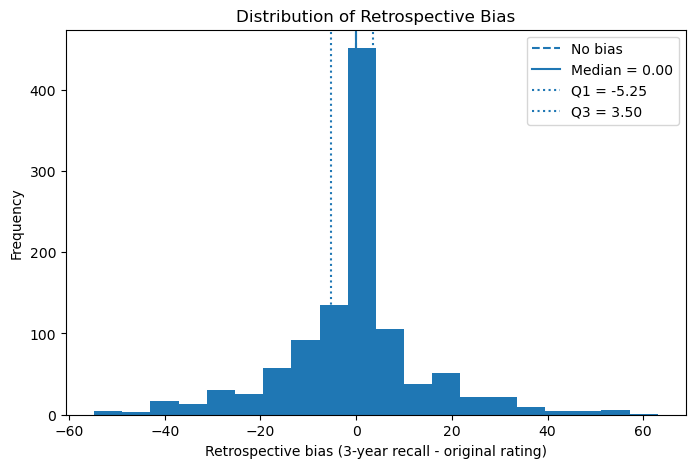

In [112]:
q1, med, q3 = bias.quantile([0.25, 0.50, 0.75])

plt.figure(figsize=(8, 5))
plt.hist(bias, bins=20)
plt.axvline(0, linestyle="--", label="No bias")
plt.axvline(med, linestyle="-", label=f"Median = {med:.2f}")
plt.axvline(q1, linestyle=":", label=f"Q1 = {q1:.2f}")
plt.axvline(q3, linestyle=":", label=f"Q3 = {q3:.2f}")

plt.xlabel("Retrospective bias (3-year recall - original rating)")
plt.ylabel("Frequency")
plt.title("Distribution of Retrospective Bias")
plt.legend()
plt.show()

## Sample description

### Descriptive Statistics

Here we simply observe at the central values, distribution and spread for each of the personality and video gaming variables, mostly for reporting purposes:

In [116]:
perso_df.describe()

,N_BL,E_BL,O_BL,A_BL,C_BL,N_FU1,E_FU1,O_FU1,A_FU1,C_FU1,...,H_FU2,AS_FU2,IMP_FU2,SS_FU2,H_FU3,AS_FU3,IMP_FU3,SS_FU3,VG_gr,outlier
count,1494.000000,1492.000000,1493.000000,1493.000000,1491.000000,1385.000000,1387.000000,1391.000000,1392.000000,1384.000000,...,1283.000000,1282.000000,1290.000000,1277.000000,1116.000000,1115.000000,1114.000000,1118.000000,1508.000000,1508.000000
mean,1.781341,2.498498,2.409746,2.606710,2.409054,1.799096,2.490084,2.412682,2.610132,2.411934,...,1.911896,2.296752,2.117866,2.607055,1.901623,2.287820,2.107783,2.609817,0.701592,0.043767
std,0.517534,0.500655,0.529188,0.502227,0.507405,0.533623,0.495622,0.533913,0.515752,0.514770,...,0.466550,0.490392,0.478357,0.488036,0.461729,0.482965,0.477455,0.477814,0.457711,0.204643
min,0.000000,0.882865,0.830060,1.004693,0.691735,0.000000,1.059656,0.631542,1.071743,0.529730,...,1.000000,1.000000,1.000000,1.277182,1.000000,1.000000,1.000000,1.033953,0.000000,0.000000
25%,1.441401,2.152668,2.071903,2.256697,2.082130,1.454808,2.140881,2.064435,2.257972,2.068868,...,1.570208,1.965382,1.803039,2.270890,1.570576,1.948510,1.789211,2.276533,0.000000,0.000000
50%,1.789241,2.482994,2.409101,2.616165,2.410236,1.807371,2.499357,2.410147,2.598078,2.412570,...,1.906846,2.281037,2.120152,2.607265,1.888817,2.280856,2.120429,2.608594,1.000000,0.000000
75%,2.137271,2.845645,2.772957,2.939241,2.744184,2.162385,2.831862,2.767035,2.951436,2.766961,...,2.217077,2.626205,2.440970,2.927454,2.198502,2.634094,2.411660,2.939504,1.000000,0.000000
max,3.450336,4.000000,4.000000,4.000000,4.000000,3.650094,4.000000,4.000000,4.000000,4.000000,...,3.769157,4.144916,3.630546,4.731638,3.251523,4.000000,3.548559,4.000000,1.000000,1.000000


In [117]:
video_df.describe()

,Ligne,VG_gr_FU2,VG_gr_FU3,VGm_aggr_FU2,VGm_novel_FU2,VGm_care_FU2,VGm_fear_FU2,VGm_play_FU2,VGm_sad_FU2,VGigd1_FU2,...,VGi_FU3,VGf_BL,VGf_FU1,VGf_FU2,VGf_FU3,VGexp_BL,VGexp_FU1,VGexp_FU2,VGexp_FU3,VGexp_bias
count,1508.000000,1289.000000,1118.000000,843.000000,845.000000,843.000000,840.000000,844.000000,841.000000,843.000000,...,1114.000000,1284.000000,1287.000000,1293.000000,1114.000000,1277.000000,1277.000000,1275.000000,1104.000000,1094.000000
mean,754.500000,0.655547,0.651163,2.971530,2.992899,2.976275,2.985714,2.964455,3.011891,1.034401,...,2.317774,2.573209,2.469308,2.477958,2.465889,7.123532,6.713391,7.113333,7.037138,-0.758455
std,435.466417,0.475374,0.476816,1.381639,1.430854,1.429053,1.419189,1.404506,1.409104,1.218427,...,2.506328,2.664995,2.584879,2.954358,2.592616,11.004214,10.481767,10.897999,10.971445,15.034620
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-54.750000
25%,377.750000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.250000
50%,754.500000,1.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.250000,2.250000,2.250000,2.250000,0.000000
75%,1131.250000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,10.500000,8.250000,10.500000,8.250000,3.500000
max,1508.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,...,9.000000,7.000000,7.000000,52.500000,7.000000,63.000000,52.500000,63.000000,63.000000,63.000000


### Correlation Analysis

In this section we analyse the correlations between variables using both the raw means and the variable changes between time points. First, we inspect visually the scatterplots between personality traits to see whether some of them might be redundant, as we are using traits from two different personality assessments:

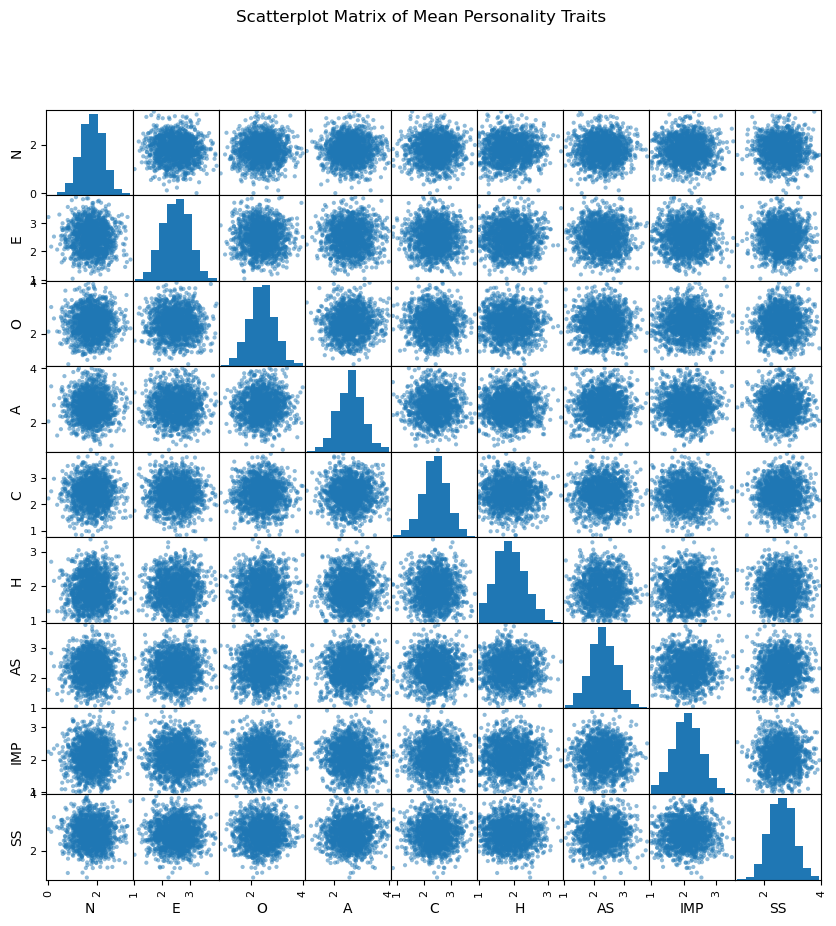

In [120]:
traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]

df_mean = pd.DataFrame()

for trait in traits:
    cols = [
        f"{trait}_BL",
        f"{trait}_FU1",
        f"{trait}_FU2",
        f"{trait}_FU3"
    ]
    
    df_mean[trait] = perso_df[cols].mean(axis=1)

scatter_matrix(df_mean, figsize=(10, 10))

plt.suptitle("Scatterplot Matrix of Mean Personality Traits")
plt.show()

We define a function to show a table with the values of the pearson correlations and the p-values adjusted for multiple comparisons:

In [122]:
def correlation_with_pvalues(df):
    cols = df.columns
    corr_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    p_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for c1, c2 in itertools.product(cols, cols):
        data = df[[c1, c2]].dropna()
        if len(data) > 1:
            x = data[c1].values.flatten()
            y = data[c2].values.flatten()
            r, p = pearsonr(x, y)
            corr_matrix.loc[c1, c2] = r
            p_matrix.loc[c1, c2] = p
        else:
            corr_matrix.loc[c1, c2] = np.nan
            p_matrix.loc[c1, c2] = np.nan

    return corr_matrix, p_matrix


def adjust_pvalues_matrix(p_matrix):
    cols = p_matrix.columns
    pvals = []
    pairs = []

    # upper triangle only
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            p = p_matrix.iloc[i, j]
            if pd.notnull(p):
                pvals.append(p)
                pairs.append((i, j))

    # FDR correction
    pvals_adj = multipletests(pvals, method="fdr_bh")[1]

    # rebuild matrix
    p_adj_matrix = p_matrix.copy()

    for (i, j), p_adj in zip(pairs, pvals_adj):
        p_adj_matrix.iloc[i, j] = p_adj
        p_adj_matrix.iloc[j, i] = p_adj

    return p_adj_matrix


def corr_with_significance(df):
    corr, pvals = correlation_with_pvalues(df)
    pvals_adj = adjust_pvalues_matrix(pvals)

    result = pd.DataFrame(index=corr.index, columns=corr.columns)

    for i in corr.index:
        for j in corr.columns:
            r = corr.loc[i, j]
            p = pvals_adj.loc[i, j]

            if pd.notnull(r):
                stars = ""
                if p < 0.001:
                    stars = "***"
                elif p < 0.01:
                    stars = "**"
                elif p < 0.05:
                    stars = "*"

                result.loc[i, j] = f"{r:.2f}{stars}"
            else:
                result.loc[i, j] = ""

    return result

In [123]:
# Within-person correlations
df_change_bl_fu1 = pd.DataFrame()
df_change_fu1_fu2 = pd.DataFrame()
df_change_fu2_fu3 = pd.DataFrame()
df_change_BL_fu3 = pd.DataFrame()

for trait in traits:
    df_change_bl_fu1[trait] = perso_df[f"{trait}_FU1"] - perso_df[f"{trait}_BL"]
    df_change_fu1_fu2[trait] = perso_df[f"{trait}_FU2"] - perso_df[f"{trait}_FU1"]
    df_change_fu2_fu3[trait] = perso_df[f"{trait}_FU3"] - perso_df[f"{trait}_FU2"]
    df_change_BL_fu3[trait] = perso_df[f"{trait}_FU3"] - perso_df[f"{trait}_BL"]

result_bl_fu1 = corr_with_significance(df_change_bl_fu1)
result_fu1_fu2 = corr_with_significance(df_change_fu1_fu2)
result_fu2_fu3 = corr_with_significance(df_change_fu2_fu3)
result_BL_fu3 = corr_with_significance(df_change_BL_fu3)

print("\n=== BL → FU1 CHANGE CORRELATIONS ===")
print(result_bl_fu1)

print("\n=== FU1 → FU2 CHANGE CORRELATIONS ===")
print(result_fu1_fu2)

print("\n=== FU2 → FU3 CHANGE CORRELATIONS ===")
print(result_fu2_fu3)

print("\n=== BL → FU3 CHANGE CORRELATIONS ===")
print(result_BL_fu3)



=== BL → FU1 CHANGE CORRELATIONS ===
           N        E        O        A        C        H       AS      IMP  \
N    1.00***    -0.03    -0.01    -0.03    -0.03     0.03     0.00     0.01   
E      -0.03  1.00***     0.01    -0.06     0.02    -0.01     0.04    -0.00   
O      -0.01     0.01  1.00***     0.01     0.01     0.02     0.03    -0.00   
A      -0.03    -0.06     0.01  1.00***     0.01     0.02    -0.01    -0.00   
C      -0.03     0.02     0.01     0.01  1.00***    -0.02    -0.02     0.02   
H       0.03    -0.01     0.02     0.02    -0.02  1.00***     0.04    -0.03   
AS      0.00     0.04     0.03    -0.01    -0.02     0.04  1.00***    -0.04   
IMP     0.01    -0.00    -0.00    -0.00     0.02    -0.03    -0.04  1.00***   
SS     -0.02     0.02     0.03    -0.05    -0.00    -0.00     0.02    -0.01   

          SS  
N      -0.02  
E       0.02  
O       0.03  
A      -0.05  
C      -0.00  
H      -0.00  
AS      0.02  
IMP    -0.01  
SS   1.00***  

=== FU1 → FU2 CHANGE

In [124]:
result_table = corr_with_significance(df_mean)

print("Correlation matrix with corrected significance:")
print(result_table)

Correlation matrix with corrected significance:
           N        E        O        A        C        H       AS      IMP  \
N    1.00***    -0.04     0.03     0.01     0.01     0.04    -0.00     0.01   
E      -0.04  1.00***    -0.03    -0.01    -0.01     0.03    -0.02    -0.02   
O       0.03    -0.03  1.00***     0.04    -0.01     0.01     0.01     0.00   
A       0.01    -0.01     0.04  1.00***     0.02     0.00     0.03    -0.02   
C       0.01    -0.01    -0.01     0.02  1.00***    -0.01     0.02     0.01   
H       0.04     0.03     0.01     0.00    -0.01  1.00***     0.00     0.04   
AS     -0.00    -0.02     0.01     0.03     0.02     0.00  1.00***     0.01   
IMP     0.01    -0.02     0.00    -0.02     0.01     0.04     0.01  1.00***   
SS     -0.01    -0.01     0.01     0.00     0.01    -0.00     0.04     0.01   

          SS  
N      -0.01  
E      -0.01  
O       0.01  
A       0.00  
C       0.01  
H      -0.00  
AS      0.04  
IMP     0.01  
SS   1.00***  


We are also interested in seeing how mean change for each of the variables might correlate with the others. Here, we calculate this for the overall change from the first to the last assessments:

In [127]:
# Personality change correlations
df_change = pd.DataFrame()

for trait in traits:
    df_change[trait] = perso_df[f"{trait}_FU3"] - perso_df[f"{trait}_BL"]
# Add video exposure variables
#df_change["VGexp_FU23"] = video_df["VGexp_FU3"]-video_df["VGexp_FU2"]
#df_change["VGexp_FU12"] = video_df["VGexp_FU2"]-video_df["VGexp_FU1"]
#df_change["VGexp_FU1BL"] = video_df["VGexp_FU1"]-video_df["VGexp_BL"]
df_change["VGexp"] = video_df["VGexp_FU3"]-video_df["VGexp_BL"]
result_change = corr_with_significance(df_change)
# Wave-to-wave changes
print(result_change)

             N        E        O        A        C        H       AS      IMP  \
N      1.00***     0.02    -0.03     0.02     0.06     0.01     0.02     0.02   
E         0.02  1.00***     0.00     0.05    -0.00     0.01    -0.02    -0.06   
O        -0.03     0.00  1.00***    -0.02    -0.00    -0.02    -0.00    -0.02   
A         0.02     0.05    -0.02  1.00***     0.01     0.01    -0.02     0.02   
C         0.06    -0.00    -0.00     0.01  1.00***    -0.02     0.03    -0.03   
H         0.01     0.01    -0.02     0.01    -0.02  1.00***     0.07    -0.01   
AS        0.02    -0.02    -0.00    -0.02     0.03     0.07  1.00***    -0.02   
IMP       0.02    -0.06    -0.02     0.02    -0.03    -0.01    -0.02  1.00***   
SS        0.02    -0.08    -0.00     0.00     0.02    -0.03     0.03     0.03   
VGexp     0.05     0.00    -0.03    -0.02     0.02    -0.01     0.05    -0.01   

            SS    VGexp  
N         0.02     0.05  
E        -0.08     0.00  
O        -0.00    -0.03  
A   

### Differences gamers-non gamers

Although the main idea for this study is to treat video gaming as an exposure variable, here we calculate the overall differences between gamers and non-gamers in personality traits, as they might reflect what previous literature has observed. As the binary group variable is available for FU2 and FU3, we see the differences in personality cross-sectionally in those time points.

First, for FU2:

In [132]:
diff_df = perso_df.copy()
diff_df["videogame"] = video_df[
    "VG_gr_FU2"
]
diff_df = diff_df[diff_df["videogame"].isin([0, 1])]
traits_fu2 = ["N_FU2", "E_FU2", "O_FU2", "A_FU2", "C_FU2", "H_FU2", "AS_FU2", "IMP_FU2", "SS_FU2"]

results = []

for col in traits_fu2:
    g0 = diff_df[diff_df["videogame"] == 0][col].dropna()
    g1 = diff_df[diff_df["videogame"] == 1][col].dropna()
    m0, m1 = g0.mean(), g1.mean()
    t, p = ttest_ind(g0, g1, equal_var=False)
    d = (m1 - m0) / ((g0.std()**2 + g1.std()**2) / 2)**0.5
    results.append({
        "Trait": col,
        "Mean_non_gamers": m0,
        "Mean_gamers": m1,
        "t": t,
        "p": p,
        "Cohens_d": d
    })

results_df = pd.DataFrame(results).round(3)
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]
print(results_df)

     Trait  Mean_non_gamers  Mean_gamers      t      p  Cohens_d     p_adj
0    N_FU2            1.830        1.798  1.013  0.312    -0.060  0.408857
1    E_FU2            2.451        2.528 -2.511  0.012     0.148  0.054000
2    O_FU2            2.425        2.391  1.080  0.280    -0.064  0.408857
3    A_FU2            2.606        2.590  0.522  0.602    -0.031  0.677250
4    C_FU2            2.568        2.341  7.485  0.000    -0.438  0.000000
5    H_FU2            1.911        1.913 -0.067  0.946     0.004  0.946000
6   AS_FU2            2.327        2.280  1.655  0.098    -0.097  0.220500
7  IMP_FU2            2.100        2.128 -0.999  0.318     0.058  0.408857
8   SS_FU2            2.573        2.625 -1.763  0.078     0.105  0.220500


And then for FU3:

In [134]:
diff_df = perso_df.copy()
diff_df["videogame"] = video_df[
    "VG_gr_FU3"
]
diff_df = diff_df[diff_df["videogame"].isin([0, 1])]
traits_fu3 = ["N_FU3", "E_FU3", "O_FU3", "A_FU3", "C_FU3", "H_FU3", "AS_FU3", "IMP_FU3", "SS_FU3"]

results = []

for col in traits_fu3:
    g0 = diff_df[diff_df["videogame"] == 0][col].dropna()
    g1 = diff_df[diff_df["videogame"] == 1][col].dropna()
    m0, m1 = g0.mean(), g1.mean()
    t, p = ttest_ind(g0, g1, equal_var=False)
    d = (m1 - m0) / ((g0.std()**2 + g1.std()**2) / 2)**0.5
    results.append({
        "Trait": col,
        "Mean_non_gamers": m0,
        "Mean_gamers": m1,
        "t": t,
        "p": p,
        "Cohens_d": d
    })

results_df = pd.DataFrame(results).round(3)
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]
print(results_df)

     Trait  Mean_non_gamers  Mean_gamers      t      p  Cohens_d    p_adj
0    N_FU3            1.800        1.786  0.398  0.691    -0.025  0.93200
1    E_FU3            2.501        2.496  0.166  0.868    -0.010  0.93200
2    O_FU3            2.393        2.406 -0.380  0.704     0.024  0.93200
3    A_FU3            2.585        2.582  0.085  0.932    -0.005  0.93200
4    C_FU3            2.505        2.364  4.345  0.000    -0.272  0.00000
5    H_FU3            1.905        1.902  0.103  0.918    -0.006  0.93200
6   AS_FU3            2.227        2.320 -3.053  0.002     0.193  0.00900
7  IMP_FU3            2.089        2.117 -0.937  0.349     0.060  0.78525
8   SS_FU3            2.649        2.591  1.902  0.058    -0.120  0.17400


### Sex differences

It is well established that personality traits' scores differ between sexes. In this study, we examine these differences as a quality check of our dataset. To do so, we perform paired t-tests for each personality trait and apply corrections for multiple comparisons. Here we take the examples of BL and FU3 to see the cross-sectional differences in the first and last assessments.

In [138]:
diff_df = perso_df.copy()
diff_df["sex"] = meta_df[
    "gender de D_BL"
]
diff_df = diff_df[diff_df["sex"].isin([1, 2])]
traits_fu2 = ["N_BL", "E_BL", "O_BL", "A_BL", "C_BL", "H_BL", "AS_BL", "IMP_BL", "SS_BL"]

results = []

for col in traits_fu2:
    g0 = diff_df[diff_df["sex"] == 1][col].dropna()
    g1 = diff_df[diff_df["sex"] == 2][col].dropna()
    m0, m1 = g0.mean(), g1.mean()
    t, p = ttest_ind(g0, g1, equal_var=False)
    d = (m1 - m0) / ((g0.std()**2 + g1.std()**2) / 2)**0.5
    results.append({
        "Trait": col,
        "Mean_males": m0,
        "Mean_females": m1,
        "t": t,
        "p": p,
        "Cohens_d": d
    })

results_df = pd.DataFrame(results).round(3)
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]
print(results_df)

    Trait  Mean_males  Mean_females      t      p  Cohens_d     p_adj
0    N_BL       1.798         1.767  1.130  0.259    -0.059  0.459000
1    E_BL       2.475         2.515 -1.525  0.127     0.079  0.459000
2    O_BL       2.426         2.398  1.023  0.306    -0.053  0.459000
3    A_BL       2.617         2.595  0.813  0.416    -0.042  0.500625
4    C_BL       2.401         2.421 -0.765  0.445     0.040  0.500625
5    H_BL       1.916         1.887  1.207  0.228    -0.063  0.459000
6   AS_BL       2.320         2.286  1.366  0.172    -0.071  0.459000
7  IMP_BL       2.081         2.112 -1.297  0.195     0.068  0.459000
8   SS_BL       2.606         2.603  0.130  0.897    -0.007  0.897000


In [140]:
diff_df = perso_df.copy()
diff_df["sex"] = meta_df[
    "gender de D_BL"
]
diff_df = diff_df[diff_df["sex"].isin([1, 2])]
traits_fu3 = ["N_FU3", "E_FU3", "O_FU3", "A_FU3", "C_FU3", "H_FU3", "AS_FU3", "IMP_FU3", "SS_FU3"]

results = []

for col in traits_fu3:
    g0 = diff_df[diff_df["sex"] == 1][col].dropna()
    g1 = diff_df[diff_df["sex"] == 2][col].dropna()
    m0, m1 = g0.mean(), g1.mean()
    t, p = ttest_ind(g0, g1, equal_var=False)
    d = (m1 - m0) / ((g0.std()**2 + g1.std()**2) / 2)**0.5
    results.append({
        "Trait": col,
        "Mean_males": m0,
        "Mean_females": m1,
        "t": t,
        "p": p,
        "Cohens_d": d
    })

results_df = pd.DataFrame(results).round(3)
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]
print(results_df)

     Trait  Mean_males  Mean_females      t      p  Cohens_d     p_adj
0    N_FU3       1.811         1.773  1.184  0.236    -0.071  0.480600
1    E_FU3       2.466         2.527 -1.903  0.057     0.115  0.294000
2    O_FU3       2.412         2.399  0.380  0.704    -0.023  0.946286
3    A_FU3       2.607         2.555  1.665  0.096    -0.100  0.294000
4    C_FU3       2.412         2.416 -0.127  0.899     0.008  0.998000
5    H_FU3       1.918         1.887  1.110  0.267    -0.067  0.480600
6   AS_FU3       2.310         2.262  1.657  0.098    -0.100  0.294000
7  IMP_FU3       2.104         2.114 -0.337  0.736     0.020  0.946286
8   SS_FU3       2.607         2.607 -0.002  0.998     0.000  0.998000


In [143]:
traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
df_change = pd.DataFrame()
for trait in traits:
    df_change[f"{trait}_BL_FU1"] = perso_df[f"{trait}_FU1"] - perso_df[f"{trait}_BL"]
    df_change[f"{trait}_FU1_FU2"] = perso_df[f"{trait}_FU2"] - perso_df[f"{trait}_FU1"]
    df_change[f"{trait}_FU2_FU3"] = perso_df[f"{trait}_FU3"] - perso_df[f"{trait}_FU2"]

results = []

for col in df_change.columns:
    data = df_change[[col]].copy()
    data["gender"] = meta_df["gender de D_BL"]
    data = data.dropna()
    
    group1 = data[data["gender"] == 1][col]  # e.g., males
    group2 = data[data["gender"] == 2][col]  # e.g., females
    
    t, p = ttest_ind(group1, group2, equal_var=False)
    
    results.append({
        "variable": col,
        "mean_males": group1.mean(),
        "mean_females": group2.mean(),
        "t": t,
        "p": p
    })

df_results = pd.DataFrame(results)
df_results["p_adj"] = multipletests(df_results["p"], method="fdr_bh")[1]
print(df_results)

       variable  mean_males  mean_females         t         p     p_adj
0      N_BL_FU1    0.010413      0.016697 -0.379884  0.704091  0.884784
1     N_FU1_FU2    0.022002      0.011861  0.546620  0.584738  0.870741
2     N_FU2_FU3   -0.013711     -0.018585  0.252304  0.800854  0.888882
3      E_BL_FU1    0.015547     -0.008658  1.473841  0.140759  0.870741
4     E_FU1_FU2   -0.013284      0.015825 -1.615761  0.106398  0.870741
5     E_FU2_FU3   -0.005708     -0.004302 -0.075316  0.939977  0.939977
6      O_BL_FU1    0.007705      0.006080  0.095617  0.923839  0.939977
7     O_FU1_FU2   -0.012072     -0.005643 -0.357291  0.720935  0.884784
8     O_FU2_FU3    0.016168     -0.004002  1.041295  0.297972  0.870741
9      A_BL_FU1    0.015448     -0.000028  0.922344  0.356515  0.870741
10    A_FU1_FU2   -0.010261     -0.014140  0.223685  0.823039  0.888882
11    A_FU2_FU3   -0.009391     -0.016757  0.392409  0.694833  0.884784
12     C_BL_FU1   -0.002779     -0.012732  0.610429  0.541681  0

### Differences gamers-non gamers controlling for sex

We will create logistic regression models to examine whether gaming precdicts the probability of gaming while controlling for sex.

In [150]:
perso_df

,N_BL,E_BL,O_BL,A_BL,C_BL,N_FU1,E_FU1,O_FU1,A_FU1,C_FU1,...,AS_FU2,IMP_FU2,SS_FU2,H_FU3,AS_FU3,IMP_FU3,SS_FU3,VG_gr,outlier,outlier_consistent
0,1.136162,2.511047,2.162642,1.965146,1.834863,1.055072,2.365261,2.705480,2.009258,2.154964,...,2.700700,2.541868,2.479013,2.241595,2.692635,2.904535,2.707265,1,0,<NA>
1,1.846294,3.444541,2.194688,3.204541,3.180140,1.813978,3.711414,2.465162,3.062110,2.670929,...,2.886338,2.448635,2.461674,2.024283,3.030473,2.848231,2.854003,1,0,<NA>
2,1.019528,2.843286,1.574271,1.609477,2.118414,0.714863,3.027018,1.598058,2.075931,2.523482,...,2.931672,2.484793,2.215848,NaN,NaN,NaN,NaN,1,0,<NA>
3,2.242125,2.887497,1.321484,2.542928,2.030672,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,<NA>
4,2.181373,2.625100,NaN,2.813673,NaN,2.608618,2.045453,1.927208,2.654407,1.686265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,1.820668,2.296958,2.947227,2.909054,1.517090,2.064048,1.893881,2.428754,3.102182,1.666834,...,2.573954,1.857792,3.364123,NaN,NaN,NaN,NaN,0,0,<NA>
1504,1.408972,2.873157,2.817152,2.525013,3.065247,1.699738,2.794746,3.542057,2.833391,2.498408,...,2.800984,1.771757,3.508864,2.124135,2.623884,1.526144,3.498296,0,0,<NA>
1505,1.614678,3.025825,2.843797,1.863391,2.540959,1.937922,2.576623,2.586498,1.785713,2.333951,...,1.713980,1.770359,2.563931,2.542717,1.607858,2.409677,2.743192,1,0,<NA>
1506,2.362582,2.467886,1.709410,2.403939,1.857959,2.290700,2.397057,NaN,2.179254,1.915236,...,1.680191,1.300379,2.550900,NaN,NaN,NaN,NaN,0,0,<NA>


In [151]:
import pandas as pd
import statsmodels.api as sm

# Combine all relevant variables into one dataframe
data = df_mean.copy()
data["VG_gr"] = perso_df["VG_gr"]
data["sex"] = diff_df["sex"]

# Drop missing values (important for regression)
data = data.dropna()

traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]

results = {}

for trait in traits:
    X = data[[trait, "sex"]]
    X = sm.add_constant(X)  # adds intercept
    y = data["VG_gr"]
    
    model = sm.Logit(y, X).fit(disp=0)
    results[trait] = model
    
    print(f"\n=== Logistic regression for {trait} ===")
    print(model.summary())


=== Logistic regression for N ===
                           Logit Regression Results                           
Dep. Variable:                  VG_gr   No. Observations:                 1477
Model:                          Logit   Df Residuals:                     1474
Method:                           MLE   Df Model:                            2
Date:                Thu, 01 Oct 2026   Pseudo R-squ.:                 0.02655
Time:                        11:38:27   Log-Likelihood:                -868.08
converged:                       True   LL-Null:                       -891.76
Covariance Type:            nonrobust   LLR p-value:                 5.196e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3323      0.296      7.871      0.000       1.752       2.913
N             -0.1174      0.119     -0.988      0.323      -0.350       0.115
sex           -0.

In [152]:
import pandas as pd
import statsmodels.api as sm

traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
timepoints = ["BL", "FU1", "FU2", "FU3"]

data = perso_df.copy()
data["sex"] = diff_df["sex"]
data["VG_gr"] = perso_df["VG_gr"]

adjusted = pd.DataFrame(index=data.index)

for t in traits:
    for tp in timepoints:
        col = f"{t}_{tp}"
        
        tmp = data[[col, "sex"]].dropna()
        X = sm.add_constant(tmp["sex"])
        y = tmp[col]
        
        model = sm.OLS(y, X).fit()
        
        # residuals = trait with sex effect removed
        adjusted.loc[tmp.index, col] = model.resid

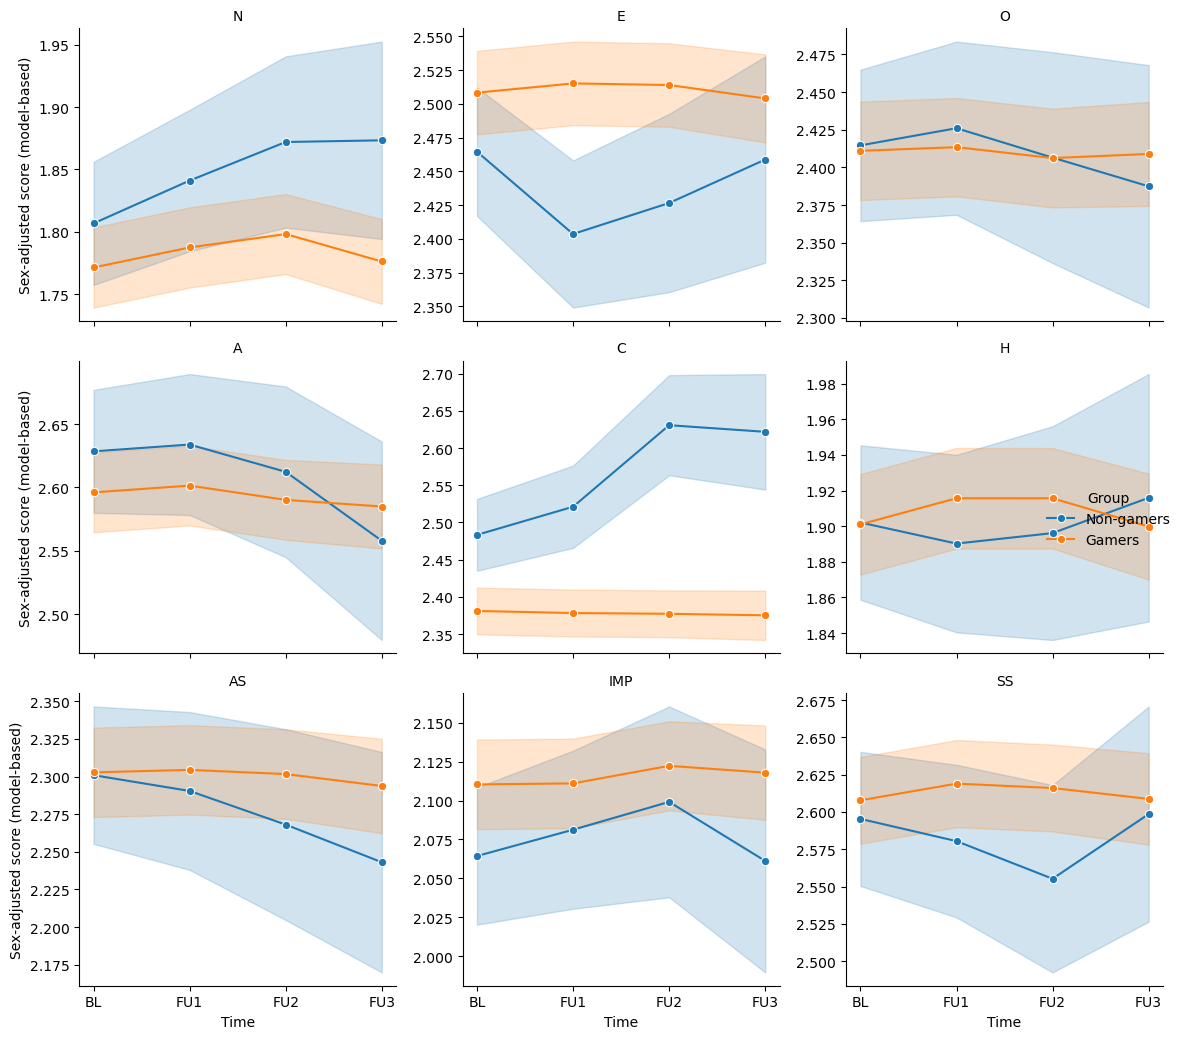

In [153]:
traits = ["N", "E", "O", "A", "C", "H", "AS", "IMP", "SS"]
timepoints = ["BL", "FU1", "FU2", "FU3"]

# Long reshape
dfs = []

for trait in traits:
    cols = [f"{trait}_{tp}" for tp in timepoints]
    
    tmp = perso_df[cols].copy()
    tmp["VG_gr"] = perso_df["VG_gr"]
    tmp["sex"] = diff_df["sex"]
    tmp["participant_id"] = perso_df.index  # adjust if needed
    
    tmp_long = tmp.melt(
        id_vars=["VG_gr", "sex", "participant_id"],
        var_name="time",
        value_name="score"
    )
    
    tmp_long["time"] = tmp_long["time"].str.replace(f"{trait}_", "")
    tmp_long["trait"] = trait
    
    dfs.append(tmp_long)

df_long = pd.concat(dfs).dropna()

# ensure proper ordering
df_long["time"] = pd.Categorical(df_long["time"], categories=timepoints, ordered=True)

# Fit models + predictions with CI
pred_list = []

for trait in traits:
    df_trait = df_long[df_long["trait"] == trait]
    
    model = smf.ols(
        "score ~ VG_gr * time + sex",
        data=df_trait
    ).fit()
    
    # prediction grid
    pred_df = pd.DataFrame({
        "VG_gr": [0]*len(timepoints) + [1]*len(timepoints),
        "time": timepoints * 2,
        "sex": df_trait["sex"].mean()
    })
    
    # get prediction + confidence intervals
    pred_res = model.get_prediction(pred_df).summary_frame(alpha=0.05)
    
    pred_df["pred"] = pred_res["mean"]
    pred_df["ci_low"] = pred_res["mean_ci_lower"]
    pred_df["ci_high"] = pred_res["mean_ci_upper"]
    
    pred_df["trait"] = trait
    pred_df["group"] = pred_df["VG_gr"].map({0: "Non-gamers", 1: "Gamers"})
    
    pred_list.append(pred_df)

pred_all = pd.concat(pred_list)

# Plot with confidence bands
g = sns.FacetGrid(
    pred_all,
    col="trait",
    col_wrap=3,
    height=3.5,
    sharey=False,
    hue="group"
)

def plot_with_ci(data, color, **kwargs):
    # ensure correct ordering
    data = data.sort_values("time")
    
    # numeric x positions
    x = range(len(data))
    
    sns.lineplot(
        x=x,
        y=data["pred"],
        marker="o",
        color=color,
        **kwargs
    )
    
    plt.fill_between(
        x=x,
        y1=data["ci_low"],
        y2=data["ci_high"],
        alpha=0.2,
        color=color
    )

g.map_dataframe(plot_with_ci)

g.add_legend(title="Group")
g.set_axis_labels("Time", "Sex-adjusted score (model-based)")
g.set_titles("{col_name}")

# fix x-axis labels
for ax in g.axes.flat:
    ax.set_xticks(range(len(timepoints)))
    ax.set_xticklabels(timepoints)

plt.tight_layout()
plt.show()

### Exclusion Criteria

In this study, we decided to exclude participants who might be compatible with the symptomatology of Internet Gaming Disorder (IGD), as it has been oberved that personality development in this condition differs from that of non-problematic gamers and non-gamers personality developments. The items regarding video gaming addiction included in the dataset reflect most of the IGD criteria:

- “How often are your thoughts occupied with video games during the day?” (VG_igd_1)
  → Preoccupation
- “How often have you played video games although you planned not to or have you played more often or longer than you actually planned?” (VG_igd_2) → Loss of control (playing more than intended)
- “Do you feel bad when you cannot play video games?” (VG_igd_3)
  → Withdrawal symptoms (negative affect when unable to play)
- “Have you noticed that you play video games more often or longer in order to feel relaxed?” (VG_igd_4)
  → Tolerance
- “How often does your urge to play video games feel overpowering, so that you cannot resist to play?” (VG_igd_6)
  → Loss of control (compulsive engagement)
- “How often do you avoid negative feelings (boredom, anger, sadness) by playing video games?” (VG_igd_7)
  → Use of gaming to escape negative mood
- “How often have you tried to quit playing video games or restrict the time you play so far?” (VG_igd_8)
  → Unsuccessful attempts to control gaming
- “How often have you forgotten something important (e.g., homework / educational training) because you have played video games all the time?” (VG_igd_9)
  → Continued gaming despite problems

The DSM-5-TR criteria of deception and loss of interest in other activities are not directly captured by these items, while craving-related content (VG_igd_5, VG_igd_6) extends beyond the strict DSM framework.

Therefore, instead of using a polythetic diagnostic approach, the participants considered at risk will be the outliers three standard deviations above the mean either at FU2 or at FU3.

In [157]:
fu2_cols = [col for col in video_igd.columns 
            if col.endswith("_FU2") and col not in ["VGigd8a_FU2", "VGigd_func_FU2","VG_gr_FU2"]]
fu3_cols = [col for col in video_igd.columns 
            if col.endswith("_FU3") and col not in ["VGigd8a_FU3", "VGigd_func_FU3","VG_gr_FU3"]]
video_igd=video_igd.copy()
video_igd_game=video_igd[(video_igd["VG_gr_FU2"]==1)|(video_igd["VG_gr_FU3"]==1)]
video_igd_game=video_igd_game.copy()
video_igd_game["score_fu2"] = video_igd_game[fu2_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)
video_igd_game["score_fu3"] = video_igd_game[fu3_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)

In [158]:
# FU2 bounds
mean_fu2 = video_igd_game["score_fu2"].mean()
std_fu2 = video_igd_game["score_fu2"].std()

# FU3 bounds
mean_fu3 = video_igd_game["score_fu3"].mean()
std_fu3 = video_igd_game["score_fu3"].std()

# Outlier masks
mask_fu2 = (video_igd_game["score_fu2"] > mean_fu2 + 2.5*std_fu2)
mask_fu3 = (video_igd_game["score_fu3"] > mean_fu3 + 2.5*std_fu3)

# Rows with outliers (either FU2 or FU3)
outlier_rows = video_igd_game[mask_fu2 | mask_fu3]

print("There are", outlier_rows.shape[0], "outliers.")

There are 6 outliers.
